# Čišćenje i priprema podataka

U prethodnom notebook-u utvrdili smo da je ciljna promenljiva `ConvertedCompYearly` i proverili da je
Stack Overflow izveo doslednom konverzijom valuta. Usput smo videli i da je ima samo **23.928 od
49.123 ispitanika**, dakle nešto manje od polovine.

Ovaj notebook prati četiri koraka čišćenja podataka — uklanjanje duplikata, ispravljanje strukturnih
grešaka, obradu netipičnih vrednosti i rešavanje nedostajućih vrednosti — i završava se podelom na
trening i test skup i čuvanjem očišćenog skupa.

Pre svega toga treba da odgovorimo na pitanje koje određuje sve ostalo: **na kojim redovima uopšte
radimo.**

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.insert(0, str(Path.cwd().parent / "src"))
from data_loader import load_raw

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

df, schema = load_raw()

reported_overall = df["ConvertedCompYearly"].notna()
print(f"redova: {len(df):,}   kolona: {len(df.columns)}")
print(f"prijavilo kompenzaciju: {reported_overall.sum():,} "
      f"({100 * reported_overall.mean():.1f}%)")

redova: 49,123   kolona: 170
prijavilo kompenzaciju: 23,928 (48.7%)


## 1. Hipoteza 2 — koje redove modelujemo

Nedostajuću vrednost u ciljnoj promenljivoj ne možemo da imputiramo. Popuniti platu značilo bi
izmisliti tačan odgovor pa naučiti model na sopstvenoj izmišljotini — model bi tada naučio naše
pravilo popunjavanja umesto stvarne veze u podacima. Ostaje nam da takve redove izbacimo, postupak
koji smo na predavanjima zvali **listwise brisanje**.

Problem je što je takvo brisanje bezbedno samo ako vrednosti nedostaju potpuno slučajno (MCAR). Ako
nedostaju zbog neke druge promenljive (MAR) ili zbog same vrednosti koja nedostaje (MNAR), brisanjem
uvodimo pristrasnost u uzorak.

Pre nego što se time pozabavimo, treba da suzimo skup na ljude o kojima uopšte govorimo.

Da to nije formalnost, videlo se već u opisu skupa: anketu ne popunjavaju samo programeri po
zanimanju, nego i oni koji tek uče da programiraju, hobisti, bivši programeri i ljudi koji rade sa
programerima. Kod tih kategorija pitanje o plati ne mora da meri istu veličinu kao kod zaposlenog
programera. Koliko je kojih i kako im izgleda prijavljena zarada, merimo odmah ispod.

> **Hipoteza:** Ispitanici koji nisu programeri po zanimanju, kao i oni koji trenutno ne rade, ne
> pripadaju istoj populaciji — iznos koji prijavljuju ne meri istu veličinu kao plata zaposlenog
> programera.
>
> **Kriterijum, postavljen unapred:** Za svaku kategoriju gledamo da li joj se međukvartilni raspon
> zarade preklapa sa onim kod developera po profesiji. Kategorija čija se raspodela **ne preklapa**
> meri nešto drugo i izostavlja se. Preklapanje samo po sebi nije dokaz da kategorija pripada istoj
> populaciji — o njoj se tada odlučuje po tome čije tržište rada modelujemo, a ne po visini iznosa.

Prvo pitanje je zato jednostavno: **da li nedostajanje pogađa sve ispitanike podjednako?** Anketu ne
popunjavaju samo zaposleni programeri, pa počinjemo od toga šta je ispitanik po zanimanju.

In [2]:
def response_rate(data, column):
    """Share of respondents that reported compensation, per category of a column."""
    grouped = data.groupby(column, dropna=False)["ConvertedCompYearly"]
    table = pd.DataFrame({
        "ukupno": grouped.size(),
        "prijavilo": grouped.count(),
    })
    table["udeo_%"] = (100 * table["prijavilo"] / table["ukupno"]).round(1)
    return table.sort_values("ukupno", ascending=False)


response_rate(df, "MainBranch")

,ukupno,prijavilo,udeo_%
MainBranch,,,
I am a developer by profession,37418,20184,53.9
"I am not primarily a developer, but I write code sometimes as part of my work/studies",4888,2183,44.7
I am learning to code,2580,362,14.0
I code primarily as a hobby,1920,313,16.3
"I used to be a developer by profession, but no longer am",1322,498,37.7
I work with developers or my work supports developers but am not a developer by profession,995,388,39.0


### Grafik 1 — udeo prijavljivanja po zanimanju

**Motivacija:** Tabela daje tačne brojeve, ali se iz nje teško vidi koliko su razlike velike jedna u
odnosu na drugu. Crtamo ih da se odnos odmah uoči.

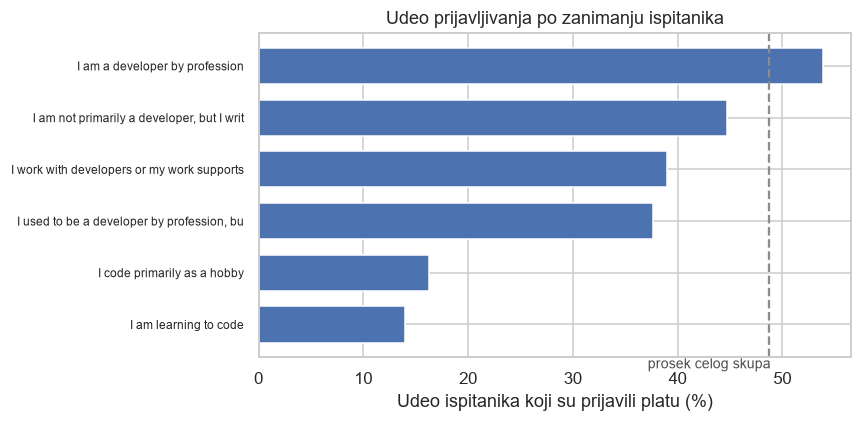

In [3]:
by_branch = response_rate(df, "MainBranch").sort_values("udeo_%")

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(range(len(by_branch)), by_branch["udeo_%"], color="#4C72B0", height=0.7)
ax.axvline(100 * df["ConvertedCompYearly"].notna().mean(), color="#8C8C8C",
           linestyle="--", linewidth=1.5)

ax.set_yticks(range(len(by_branch)))
ax.set_yticklabels([label[:42] for label in by_branch.index], fontsize=8)
ax.set_xlabel("Udeo ispitanika koji su prijavili platu (%)")
ax.set_title("Udeo prijavljivanja po zanimanju ispitanika")
ax.text(48.9, -0.85, "prosek celog skupa", color="#4C4C4C", fontsize=9, ha="right")
plt.tight_layout()
plt.show()

**Zapažanje:** Udeo je vrlo neravnomeran. Kod onih koji su se izjasnili kao developeri po profesiji
platu je prijavilo **53,9%**, a kod onih koji uče da programiraju svega **14,0%** i kod onih koji
kodiraju iz hobija **16,3%**. Između tih krajnosti su bivši developeri sa 37,7% i oni koji programiraju
uzgred kao deo posla sa 44,7%.

**Tumačenje:** Jedan deo nedostajanja nije pravo nedostajanje nego posledica toga što pitanje toj
osobi ne stoji. Student koji uči da programira najčešće nema platu programera koju bi prijavio, pa
prazno polje kod njega ne znači da nešto krije — znači da pitanje nije primenljivo.

To je važno jer nam govori da onih 48,7% sa početka nije jedan problem nego dva pomešana: ljudi kojima
pitanje ne stoji, i ljudi kojima stoji ali nisu odgovorili. Prvi se rešavaju sužavanjem populacije,
drugi ne.

Pošto zanimanje očigledno igra ulogu, sledeće pitanje je da li i radni status igra istu takvu.

In [4]:
response_rate(df, "Employment")

,ukupno,prijavilo,udeo_%
Employment,,,
Employed,33709,19485,57.8
"Independent contractor, freelancer, or self-employed",6700,3049,45.5
Student,4420,701,15.9
Not employed,2222,503,22.6
NaN,846,0,0.0
Retired,708,133,18.8
I prefer not to say,518,57,11.0


**Zapažanje:** I ovde je razlika velika. Zaposleni prijavljuju platu u **57,8%** slučajeva,
samostalni i frilenseri u **45,5%**, studenti u **15,9%**, a penzioneri u **18,8%**.

Dva reda su zanimljivija od ostalih. Kod 846 ispitanika kolona `Employment` je i sama prazna, i **od
njih nijedan nije prijavio platu** — udeo je tačno 0%. Kod onih koji su na pitanje o radnom statusu
odgovorili sa „I prefer not to say" udeo je **11,0%**, najniži u celoj tabeli.

**Tumačenje:** Prvi slučaj deluje kao ljudi koji su prekinuli popunjavanje ankete negde na početku,
pa im od tada nadalje sve nedostaje. To nije odbijanje da se odgovori nego napuštanje ankete.

Drugi slučaj je druge prirode i vredi ga zapamtiti. Ljudi koji ne žele da kažu ni kakav im je radni
status najređe kažu i koliku platu imaju. Tu se ne radi o tome da pitanje ne stoji — ono stoji, ali
osoba ne želi da odgovori. To je prvi nagoveštaj da deo nedostajanja nije slučajan, ali za sada je
samo nagoveštaj: reč je o 518 ljudi, i ne znamo da li se isti obrazac vidi i kod ostalih.

Zasad možemo da zaključimo koliko-toliko sigurno samo jedno: populacija na kojoj ima smisla modelovati
platu su ljudi koji rade kao programeri i koji trenutno imaju posao.

### Koga tačno zadržavamo

Rečenica „programeri koji imaju posao" zvuči jasno dok se ne pokuša napisati kao uslov nad kolonama.
Tada se otvaraju dva pitanja na koja prethodne dve tabele ne odgovaraju.

Prvo, `MainBranch` ima šest kategorija, a mi smo do sada gledali samo koliko njih odgovara na pitanje o
plati. To što neka grupa retko prijavljuje platu ne znači samo po sebi da ne pripada istoj populaciji.

Drugo, među profesionalcima nisu svi klasično zaposleni — ima i samostalnih i frilensera, koji od
programiranja žive kao i zaposleni. Njihovo izbacivanje bi nas koštalo dela uzorka, a zadržavanje ima
smisla samo ako im je zarada uporediva sa platom zaposlenih. Prvo da vidimo koliko ih uopšte ima.

In [5]:
by_profession = df[df["MainBranch"] == "I am a developer by profession"]

response_rate(by_profession, "Employment")

,ukupno,prijavilo,udeo_%
Employment,,,
Employed,28741,16881,58.7
"Independent contractor, freelancer, or self-employed",5365,2580,48.1
Student,1232,309,25.1
Not employed,1174,358,30.5
NaN,566,0,0.0
I prefer not to say,206,30,14.6
Retired,134,26,19.4


**Zapažanje:** Među developerima po profesiji zaposlenih je **28.741**, a samostalnih i frilensera
**5.365**. Nisu, dakle, zanemarljivi — čine oko sedminu profesionalaca.

Da bismo odlučili šta sa njima i sa ostalim kategorijama, prestajemo da gledamo ko je odgovorio i
gledamo **koliko su prijavili oni koji jesu odgovorili**. Ako se neka grupa po visini zarade jasno
izdvaja, ne pripada istoj populaciji.

In [6]:
reported = df.dropna(subset=["ConvertedCompYearly"])


def compensation_by(data, column):
    """Compensation level and spread per category, for respondents who reported it."""
    grouped = data.groupby(column, dropna=False)["ConvertedCompYearly"]
    table = pd.DataFrame({
        "n": grouped.size(),
        "medijana": grouped.median().round(0),
        "IQR": (grouped.quantile(0.75) - grouped.quantile(0.25)).round(0),
        "p10": grouped.quantile(0.10).round(0),
        "p90": grouped.quantile(0.90).round(0),
    })
    return table.sort_values("n", ascending=False)


compensation_by(reported, "MainBranch")

,n,medijana,IQR,p10,p90
MainBranch,,,,,
I am a developer by profession,20184,77864.0,82243.0,11624.0,185000.0
"I am not primarily a developer, but I write code sometimes as part of my work/studies",2183,65348.0,82202.0,6000.0,175000.0
"I used to be a developer by profession, but no longer am",498,92812.0,105984.0,11121.0,227122.0
I work with developers or my work supports developers but am not a developer by profession,388,64748.0,92542.0,2140.0,188740.0
I am learning to code,362,4650.0,18000.0,61.0,54014.0
I code primarily as a hobby,313,34804.0,73039.0,1160.0,139046.0


**Zapažanje:** Dve kategorije očigledno odudaraju. Oni koji uče da programiraju imaju medijanu od
**4.650 dolara**, a hobisti **34.804** — naspram **77.864** kod developera po profesiji. Kod onih koji
uče, deseti percentil je **61 dolar** godišnje.

Ostale tri kategorije su međusobno mnogo bliže. Oni koji nisu primarno developeri imaju medijanu
65.348, oni koji rade sa developerima 64.748, a bivši developeri **92.812** — dakle više od aktivnih
profesionalaca.

**Tumačenje:** Kod onih koji uče i kod hobista prijavljena vrednost očigledno ne meri istu stvar.
Godišnji iznos od 61 dolara nije plata programera nego verovatno neki honorar, ili ispitanik uopšte
nije razumeo pitanje. Te dve grupe ne pripadaju populaciji koju modelujemo.

Nalaz kod bivših developera je iznenađenje i vredi ga zabeležiti: oni prijavljuju **veću** platu od
aktivnih. Objašnjenje je verovatno da je reč o ljudima koji su prešli u rukovođenje ili osnovali
firmu, pa i dalje rade u struci ali sebe više ne zovu developerom. Njih ipak izostavljamo, jer nam
kolone ne dozvoljavaju da tu pretpostavku proverimo, a grupa je mala — 498 ispitanika sa platom.

Brojevi u tabeli su korisni, ali ne pokazuju koliko se raspodele **preklapaju**. Dve grupe mogu imati
različite medijane a da im se najveći deo vrednosti poklapa, i tada razdvajanje ne bi ni bilo vredno.

### Grafik 2 — raspodela zarade po zanimanju

**Motivacija:** Hoćemo da vidimo koliko se raspodele zarade po kategorijama zanimanja preklapaju, a ne
samo gde su im medijane. Crtamo boxplot, pošto on prikazuje medijanu i kvartile — iste veličine koje
koristimo i za prepoznavanje netipičnih vrednosti. Zaradu prikazujemo u logaritamskom obliku, jer smo
u prethodnom notebook-u videli da je u sirovim dolarima grafik nečitljiv.

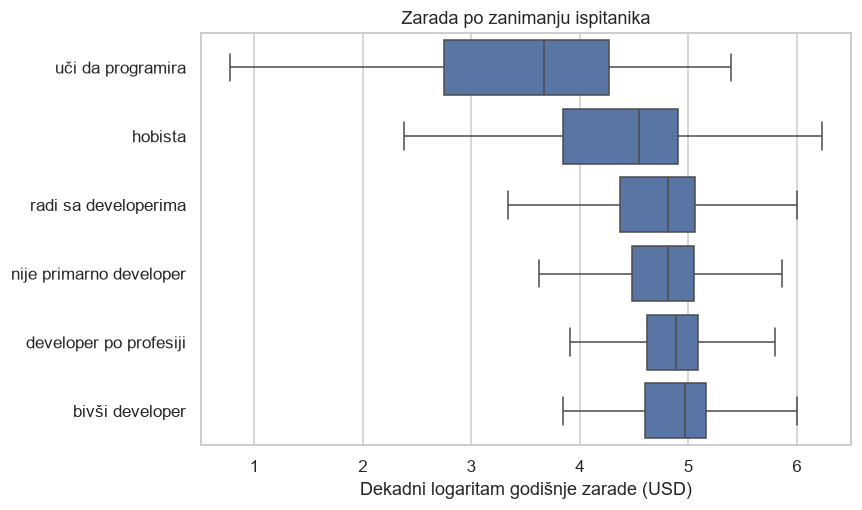

In [7]:
# Short labels, so the category names fit on the axis.
BRANCH_LABELS = {
    "I am a developer by profession": "developer po profesiji",
    "I am not primarily a developer, but I write code sometimes as part of my work/studies":
        "nije primarno developer",
    "I used to be a developer by profession, but no longer am": "bivši developer",
    "I work with developers or my work supports developers but am not a developer by profession":
        "radi sa developerima",
    "I code primarily as a hobby": "hobista",
    "I am learning to code": "uči da programira",
}

plot_data = reported.assign(
    grana=reported["MainBranch"].map(BRANCH_LABELS),
    log_comp=np.log10(reported["ConvertedCompYearly"]),
)
order = plot_data.groupby("grana")["log_comp"].median().sort_values().index

fig, ax = plt.subplots(figsize=(8, 4.8))
sns.boxplot(data=plot_data, y="grana", x="log_comp", order=order,
            color="#4C72B0", showfliers=False, ax=ax)

ax.set_xlabel("Dekadni logaritam godišnje zarade (USD)")
ax.set_ylabel("")
ax.set_title("Zarada po zanimanju ispitanika")
plt.tight_layout()
plt.show()

In [8]:
# The box edges the plot draws, written out in dollars so we can cite them.
box_edges = plot_data.groupby("grana")["ConvertedCompYearly"].agg(
    n="size",
    donja_ivica=lambda s: s.quantile(0.25),
    medijana="median",
    gornja_ivica=lambda s: s.quantile(0.75),
).round(0)

box_edges.loc[order]

,n,donja_ivica,medijana,gornja_ivica
grana,,,,
uči da programira,362,562.0,4650.0,18562.0
hobista,313,6961.0,34804.0,80000.0
radi sa developerima,388,23473.0,64748.0,116015.0
nije primarno developer,2183,30164.0,65348.0,112366.0
developer po profesiji,20184,41786.0,77864.0,124029.0
bivši developer,498,40000.0,92812.0,145984.0


**Zapažanje:** Kutije četiri gornje kategorije stoje gotovo jedna preko druge. Tabela sa ivicama kutija
to daje u dolarima: kod developera po profesiji kutija ide od **41.786 do 124.029**, kod onih koji
nisu primarno developeri od **30.164 do 112.366**, a kod onih koji rade sa developerima od **23.473 do
116.015**. Bivši developeri su pomereni naviše (40.000 do 145.984), ali im se kutija i dalje najvećim
delom poklapa sa ostalima.

Dve donje kategorije su druga priča. Kod onih koji uče da programiraju kutija se završava na **18.562
dolara**, dakle pre nego što kod developera po profesiji uopšte počne (41.786). Hobisti su između, sa
kutijom od 6.961 do 80.000.

**Tumačenje:** Grafik potvrđuje ono što je tabela nagovestila, i dodaje jednu stvar koju tabela nije
mogla. Kod onih koji uče, raspodela se **ne preklapa** sa profesionalcima — to je zaista druga
populacija i njeno uključivanje bi u model unelo ljude čija zarada nastaje na sasvim drugi način.

Kod hobista je preklapanje delimično, što je i očekivano: neki od njih verovatno imaju stalan posao u
drugoj struci pa su prijavili tu platu, a neki honorare od programiranja. Pošto ne možemo da
razlikujemo ta dva slučaja, i njih izostavljamo.

Za tri kategorije u sredini grafik ne daje osnov da ih razdvajamo po visini zarade. Njih ipak
izostavljamo iz drugog razloga — nisu programeri po zanimanju, pa plata koju prijavljuju pripada
drugom tržištu rada, čak i kada je iznos sličan. Model koji predviđa platu programera treniramo na
programerima.

In [9]:
professionals = reported[reported["MainBranch"] == "I am a developer by profession"]

compensation_by(professionals, "Employment")

,n,medijana,IQR,p10,p90
Employment,,,,,
Employed,16881,80000.0,80073.0,13922.0,185623.0
"Independent contractor, freelancer, or self-employed",2580,76545.0,87000.0,8000.0,185623.0
Not employed,358,69822.0,89495.0,3891.0,182396.0
Student,309,16706.0,22507.0,809.0,50208.0
I prefer not to say,30,84110.0,150758.0,3539.0,295500.0
Retired,26,60544.0,81058.0,5779.0,177808.0


**Zapažanje:** Zaposleni i samostalni su po visini zarade vrlo blizu — medijana **80.000** naspram
**76.545 dolara**. Ali IQR je kod samostalnih veći, **87.000** naspram 80.073.

Studenti koji se izjašnjavaju kao developeri po profesiji imaju medijanu od svega 16.706, a
nezaposleni 69.822.

**Tumačenje:** Kod samostalnih zarada je na sličnom nivou ali **razuđenija**, što ima smisla — prihod
frilensera zavisi od broja poslova u godini, dok je plata zaposlenog ugovorena.

Poređenje na celom skupu, međutim, meša i sastav po zemljama. Ako samostalnih ima proporcionalno više
u zemljama sa nižim platama, razlika koju vidimo bila bi posledica geografije, a ne oblika
zaposlenja. Zato isto poređenje ponavljamo unutar dve pojedinačne zemlje sa najviše ispitanika.

In [10]:
# The two employment states that mean the person currently earns from work.
WORKING = ["Employed", "Independent contractor, freelancer, or self-employed"]

for country in ["United States of America", "Germany"]:
    subset = professionals[
        (professionals["Country"] == country) & professionals["Employment"].isin(WORKING)
    ]
    print(country)
    print(compensation_by(subset, "Employment")[["n", "medijana", "IQR"]].to_string())
    print()

United States of America
                                                         n  medijana       IQR
Employment                                                                    
Employed                                              3897  154765.0   85000.0
Independent contractor, freelancer, or self-employed   320  129000.0  122000.0

Germany
                                                         n  medijana      IQR
Employment                                                                   
Employed                                              1540   83531.0  40373.0
Independent contractor, freelancer, or self-employed   133  104413.0  81210.0



**Zapažanje:** Unutar iste zemlje razlika ne ide na istu stranu. U Sjedinjenim Državama samostalni
zarađuju **manje** od zaposlenih (medijana 129.000 naspram 154.765), a u Nemačkoj **više** (104.413
naspram 83.531). Ono što jeste dosledno je rasipanje: IQR je kod samostalnih veći u obe zemlje —
122.000 naspram 85.000 u SAD, i 81.210 naspram 40.373 u Nemačkoj.

**Tumačenje:** Pošto smer razlike zavisi od zemlje, samostalni nisu grupa koja sistematski zarađuje
više ili manje. Nemaju drugačiji nivo zarade, nego **manje predvidiv** nivo zarade.

To je argument da ih zadržimo. Oni od programiranja žive, njihova zarada je na istom nivou kao kod
zaposlenih, i donose nam 2.580 dodatnih ispitanika sa prijavljenom platom. Veće rasipanje znači da će
model kod njih grešiti više, ali to nije razlog da ih izbacimo — to je nešto što model može da uzme u
obzir ako mu oblik zaposlenja damo kao promenljivu.

Nezaposlene, studente, penzionere i one koji nisu hteli da odgovore izostavljamo. Kod njih prijavljena
vrednost ili se odnosi na neki raniji posao, ili nije uporediva sa platom iz aktuelnog radnog odnosa.

### Verdikt i odluka o populaciji

**Hipoteza je potvrđena za one koji uče da programiraju i za hobiste, a opovrgnuta za samostalne i
frilensere.** Kod onih koji uče kutija se završava na **18.562 dolara**, pre nego što kod developera
po profesiji uopšte počne (**41.786**) — raspodele se ne preklapaju, pa je reč o drugoj populaciji.
Kod samostalnih se, nasuprot tome, smer razlike menja od zemlje do zemlje: u Sjedinjenim Državama
zarađuju manje (129.000 naspram 154.765), a u Nemačkoj više (104.413 naspram 83.531). Nemaju,
dakle, drugačiji nivo zarade nego samo razuđeniji, pa ostaju u uzorku.

Modelujemo ispitanike koji ispunjavaju oba uslova:

- `MainBranch` je **„I am a developer by profession"** — programiranje im je zanimanje, pa je plata
  koju prijavljuju plata sa tržišta rada koje modelujemo;
- `Employment` je **„Employed"** ili **„Independent contractor, freelancer, or self-employed"** —
  trenutno rade i imaju tekuću zaradu.

`Employment` zadržavamo kao promenljivu, da model može da razlikuje ta dva oblika rada.

Ova odluka ne rešava problem nedostajućih plata — ona samo iz njega uklanja onaj deo koji potiče od
ljudi kojima pitanje uopšte ne stoji. Koliko je od početnog nedostajanja time objašnjeno, a koliko
ostaje, vidimo u sledećoj ćeliji.

In [11]:
population = df[
    (df["MainBranch"] == "I am a developer by profession")
    & df["Employment"].isin(WORKING)
].copy()

reported_in_population = population["ConvertedCompYearly"].notna()

print(f"ceo dataset:                    {len(df):>7,}")
print(f"populacija koju modelujemo:     {len(population):>7,}")
print(f"  od toga prijavilo platu:      {reported_in_population.sum():>7,} "
      f"({100 * reported_in_population.mean():.1f}%)")
print(f"  i dalje nedostaje:            {(~reported_in_population).sum():>7,} "
      f"({100 * reported_in_population.eq(False).mean():.1f}%)")
print()
print(f"nedostajanje pre sužavanja:     {100 * df['ConvertedCompYearly'].isna().mean():>6.1f}%")
print(f"nedostajanje posle sužavanja:   {100 * (~reported_in_population).mean():>6.1f}%")
print()
print("provera da filter daje ono što smo opisali:")
print(f"  vrednosti u MainBranch: {population['MainBranch'].unique().tolist()}")
print(f"  vrednosti u Employment: {sorted(population['Employment'].unique().tolist())}")

ceo dataset:                     49,123
populacija koju modelujemo:      34,106
  od toga prijavilo platu:       19,461 (57.1%)
  i dalje nedostaje:             14,645 (42.9%)

nedostajanje pre sužavanja:       51.3%
nedostajanje posle sužavanja:     42.9%

provera da filter daje ono što smo opisali:
  vrednosti u MainBranch: ['I am a developer by profession']
  vrednosti u Employment: ['Employed', 'Independent contractor, freelancer, or self-employed']


**Zapažanje:** Populacija ima **34.106 ispitanika**, od kojih je platu prijavilo **19.461 (57,1%)**.
Nedostajanje je sa 51,3% palo na **42,9%** — dakle sužavanjem je objašnjeno svega oko osam procentnih
poena.

**Tumačenje:** Ovo je najvažniji nalaz sekcije, i nije onaj koji smo očekivali kad smo krenuli.
Pretpostavka da veliki deo praznih polja potiče od ljudi kojima pitanje ne stoji **pokazala se
uglavnom netačnom**. Studenti i hobisti jesu obarali ukupan prosek, ali ih ima premalo da bi objasnili
razmere problema.

Ostaje **14.645 ljudi koji rade kao programeri, imaju platu, i nisu je prijavili**. Kod njih pitanje
nije neprimenljivo — oni su jednostavno preskočili odgovor. To je odbijanje, ne nepostojanje podatka, i
prethodna analiza nam je već dala nagoveštaj kuda to vodi: ispitanici koji nisu hteli da otkriju ni
radni status najređe su otkrivali i platu.

Ako je razlog za ćutanje povezan sa samom visinom plate, reč je o MNAR-u. Na predavanjima smo taj tip
nedostajanja učili kao najopasniji, i to baš na primeru da bogati ne otkrivaju platu. U tom slučaju
brisanje tih redova ne bi bilo bezbedno, nego bi nam iskrivilo uzorak.

Da li je tako, ne možemo da tvrdimo na osnovu jednog nagoveštaja iz tabele. To je pitanje za sledeću
sekciju.

## 2. Hipoteza 3 — da li je nedostajanje plate slučajno

Pre nego što postavimo hipotezu, treba da budemo iskreni oko toga šta uopšte možemo da proverimo.

MNAR znači da nedostajanje zavisi od **same vrednosti koja nedostaje** — da neko ćuti baš zato što mu
je plata visoka ili niska. To se iz ovih podataka **ne može dokazati ni oboriti**, jer bismo za proveru
morali da znamo plate onih koji ih nisu prijavili. Da ih znamo, ne bismo ni imali problem.

Ono što možemo da proverimo jeste da li nedostajanje zavisi od obeležja koja o ispitaniku **ipak
imamo** — zemlje, godina iskustva, obrazovanja, veličine firme. Ta provera razdvaja MCAR od ostalog:

- ako nedostajanje ne zavisi ni od čega što posmatramo, MCAR ne možemo da odbacimo — ali ni da ga
  potvrdimo, jer MNAR ostaje neproverljiv bez samih nedostajućih plata;
- ako zavisi, nedostajanje sigurno **nije** MCAR, pa brisanje menja sastav uzorka.

> **Hipoteza:** Verovatnoća da ispitanik prijavi platu zavisi od njegovih posmatranih obeležja.
>
> **Kriterijum, postavljen unapred:** Hipoteza je potvrđena ako se udeo prijavljivanja između
> kategorija bar jednog obeležja razlikuje za **više od 10 procentnih poena**, uz statističku
> značajnost na pragu **0,05**. Uz p-vrednost obavezno gledamo i veličinu efekta, jer pri 34.106
> ispitanika u populaciji i beznačajne razlike ispadaju značajne.

### Prvo da razdvojimo dve različite stvari

Ranije smo videli da 846 ispitanika kojima je i `Employment` prazan nije prijavilo platu — nijedan.
To liči na ljude koji su prekinuli anketu, a ne na one koji su odbili baš pitanje o plati. Ako takvih
ima mnogo, oni bi zamaglili svaku dalju analizu: kod njih nedostaje sve, pa bi svako obeležje delovalo
povezano sa nedostajanjem plate.

Da bismo ih odvojili, treba nam grupa pitanja koja u upitniku stoje **oko** pitanja o plati. Ko nije
odgovorio ni na jedno od njih, do tog dela ankete najverovatnije nije ni stigao.

Redosled pitanja ne čitamo iz redosleda kolona u fajlu, nego iz `survey_results_schema.csv`, gde svaka
kolona nosi oznaku pitanja iz kog je nastala. Ispis ispod pokazuje i zašto ta razlika nije sitnica.

In [12]:
# The schema records which questionnaire item each column came from, so the order
# of the questions is read from there and not from the order of the columns.
question_number = (schema.drop_duplicates(subset="qname")
                   .set_index("qname")["qid"].str.extract(r"(\d+)")[0].astype(float))

for column in ["Age", "Employment", "OrgSize", "Country", "CompTotal",
               "ICorPM", "RemoteWork", "ConvertedCompYearly"]:
    number = question_number.get(column, np.nan)
    place = "nije anketno pitanje" if pd.isna(number) else f"pitanje {int(number):>3}"
    print(f"{column:<21} {place:<20}   (kolona {list(df.columns).index(column):>3} u fajlu)")

Age                   pitanje   4            (kolona   2 u fajlu)
Employment            pitanje   7            (kolona   4 u fajlu)
OrgSize               pitanje  16            (kolona  13 u fajlu)
Country               pitanje  20            (kolona  59 u fajlu)
CompTotal             pitanje  22            (kolona  61 u fajlu)
ICorPM                pitanje  23            (kolona  14 u fajlu)
RemoteWork            pitanje  24            (kolona  15 u fajlu)
ConvertedCompYearly   nije anketno pitanje   (kolona 168 u fajlu)


**Zapažanje:** Pitanje o plati (`CompTotal`) je **22. po redu** u upitniku. `OrgSize` mu neposredno
prethodi, kao pitanje **16**, a `ICorPM` i `RemoteWork` dolaze odmah posle njega, kao pitanja **23** i
**24**. `ConvertedCompYearly` nema svoj broj, jer nije anketno pitanje nego kolona koju je Stack
Overflow izveo naknadno.

Redosled kolona u fajlu je nešto sasvim drugo: te tri kolone stoje na pozicijama 13, 14 i 15, a
`Country` i `CompTotal` tek na 59 i 61.

**Tumačenje:** Sva tri pitanja pripadaju istom delu upitnika kao i pitanje o plati — jedno neposredno
pre njega, dva neposredno posle. Ispitanik koji je odgovorio na bilo koje od njih bio je u tom delu
ankete i pitanje o plati je morao da vidi. Prazne sve tri kolone su zato dobar znak da anketu nije
prošao do tog mesta, a ne da je odbio baš pitanje o plati.

Da smo se oslonili na redosled kolona u fajlu, zaključili bismo da sva tri pitanja dolaze mnogo pre
plate — što, kako ispis pokazuje, nije tačno ni za dva od njih.

In [13]:
population["prijavio_platu"] = population["ConvertedCompYearly"].notna()

# The three questions that sit around the pay question in the questionnaire; all
# three empty suggests the respondent never reached that part of the survey.
PAY_SECTION_COLUMNS = ["RemoteWork", "OrgSize", "ICorPM"]
population["prekinuo_anketu"] = population[PAY_SECTION_COLUMNS].isna().all(axis=1)

quit_early = population["prekinuo_anketu"]
print(f"nisu stigli do tog dela:     {quit_early.sum():>7,} "
      f"({100 * quit_early.mean():.1f}% populacije)")
print(f"  od njih prijavilo platu:   {population.loc[quit_early, 'prijavio_platu'].sum():>7,} "
      f"({100 * population.loc[quit_early, 'prijavio_platu'].mean():.1f}%)")
print()

completed = population[~quit_early]
print(f"stigli do tog dela ankete:   {len(completed):>7,}")
print(f"  od njih prijavilo platu:   {completed['prijavio_platu'].sum():>7,} "
      f"({100 * completed['prijavio_platu'].mean():.1f}%)")

nisu stigli do tog dela:       6,189 (18.1% populacije)
  od njih prijavilo platu:     1,627 (26.3%)

stigli do tog dela ankete:    27,917
  od njih prijavilo platu:    17,834 (63.9%)


**Zapažanje:** Do dela ankete u kom stoji pitanje o plati nije stiglo **6.189 ispitanika**, dakle
18,1% populacije, i od njih je platu prijavilo svega 26,3%. Među onima koji jesu stigli — njih
**27.917** — udeo skače na **63,9%**.

**Tumačenje:** Napuštanje ankete objašnjava osetan deo problema, ali ni izbliza ceo. I među onima koji
su bili u tom delu upitnika, **preko trećine je preskočilo baš pitanje o plati**, iako su odgovorili na
pitanja koja stoje neposredno uz njega. Kod njih to nije nedostatak prilike nego odluka.

Dalju analizu radimo samo nad tom grupom. Kod onih koji nisu stigli dotle nedostaje sve, pa bi nam
svako obeležje izgledalo povezano sa nedostajanjem plate — a to bi bio zaključak o tome ko dovršava
ankete, ne o tome ko krije platu.

### Koja obeležja uopšte da gledamo

Hipoteza govori o „posmatranim obeležjima", a njih u anketi ima mnogo. Ako bismo unapred izabrali dva
ili tri i našli razliku, opravdano bi se moglo prigovoriti da smo birali ona koja nam odgovaraju.

Zato prvo prolazimo **kroz sve kategorijske kolone odjednom** i za svaku merimo koliko se udeo
prijavljivanja razlikuje između njenih kategorija. To je gruba mera — samo razmak između najnižeg i
najvišeg udela — ali dovoljna da vidimo gde uopšte ima šta da se traži. Uzimamo samo kategorije sa bar
150 ispitanika, da razmak ne bi pravila neka šačica ljudi.

In [14]:
# A category needs enough respondents for its percentage to mean anything: with
# fewer than 150, a handful of people moves it by more than a percentage point.
MIN_GROUP = 150

# Left out: the target itself and the column it is derived from; the two columns
# that define the population, which are constant here; the identifier; the two
# columns we derived ourselves; and Currency, which carries the same information
# as Country and would only repeat that finding.
EXCLUDE = {"ConvertedCompYearly", "CompTotal", "Currency", "MainBranch",
           "Employment", "ResponseId", "prijavio_platu", "prekinuo_anketu"}


def response_spread(data, column):
    """Gap between the lowest and highest response rate across a column's categories."""
    table = data.groupby(column, dropna=True)["prijavio_platu"].agg(
        n="size", udeo=lambda s: 100 * s.mean()
    )
    table = table[table["n"] >= MIN_GROUP]
    if len(table) < 2:
        return None
    return {
        "kolona": column,
        "kategorija": len(table),
        "min_%": table["udeo"].min(),
        "max_%": table["udeo"].max(),
        "raspon_pp": table["udeo"].max() - table["udeo"].min(),
    }


results = []
for column in completed.columns:
    values = completed[column]
    if column in EXCLUDE or values.dtype.kind in "fi":
        continue
    # Multi-select answers are stored as one string with ";" separators; those
    # need their own treatment and are not simple categories. The bar is low on
    # purpose, because here we only want them out of the way: skipping a
    # borderline column costs less than counting a multi-select as a category.
    # Where they are later picked out deliberately, a stricter 0.3 is used.
    if values.dropna().astype(str).str.contains(";").mean() > 0.1:
        continue
    if not 2 <= values.nunique(dropna=True) <= 200:
        continue
    row = response_spread(completed, column)
    if row:
        results.append(row)

spread = pd.DataFrame(results).sort_values("raspon_pp", ascending=False).round(1)

print(f"provereno kolona: {len(spread)}")
print()
print(spread.head(8).to_string(index=False))

provereno kolona: 32

         kolona  kategorija  min_%  max_%  raspon_pp
        Country          31   54.0   88.5       34.5
        OrgSize           9   40.0   67.5       27.5
     SODuration           7   56.0   82.7       26.7
LearnCodeChoose           3   43.8   64.9       21.1
        DevType          20   50.0   69.6       19.6
 LanguageChoice           2   65.0   80.2       15.2
     RemoteWork           5   53.8   68.2       14.4
            Age           6   54.1   67.3       13.2


**Zapažanje:** Provereno je **32 kolone**, i razmak nije mali ni kod jedne od prvih nekoliko.
Ubedljivo najveći je kod **zemlje — 34,5 procentnih poena** (54,0% do 88,5%), zatim kod **veličine
firme, 27,5** (40,0% do 67,5%) i kod `SODuration`, 26,7. Slede `LearnCodeChoose` sa 21,1 i `DevType`
sa 19,6, a prag od 10 poena prelaze i `LanguageChoice` (15,2), `RemoteWork` (14,4) i starost (13,2).

**Tumačenje:** Hipoteza je time praktično već potvrđena, i to na više obeležja odjednom, ne na jednom
srećno izabranom. Formalno je dovoljno i jedno — tvrdnja glasi da nedostajanje zavisi od nečega što
posmatramo, pa jedan slučaj obara MCAR — ali ovako znamo i **koja** obeležja su u igri, što nam treba
za odluku o modelu.

Dalje razrađujemo **zemlju**, jer ima ubedljivo najveći razmak, pa je prvi kandidat za detaljnu
proveru. Veličinu firme zadržavamo na umu za kasnije.

Ono što ova tabela ne pokazuje jeste da li su razmaci statistički značajni i koliko su zapravo veliki.
Razmak najniže i najviše kategorije je osetljiv na krajnosti, pa ga treba proveriti pravim testom.

### Grafik 3 — udeo prijavljivanja po zemljama

**Motivacija:** Iz prethodne tabele znamo da je razmak kod zemlje najveći, ali ne i kako je
raspoređen — da li ga pravi nekoliko izuzetaka ili se udeo menja postepeno. Gledamo zemlje sa bar 150
ispitanika, da udeo ne bi bio računat na šačici ljudi.

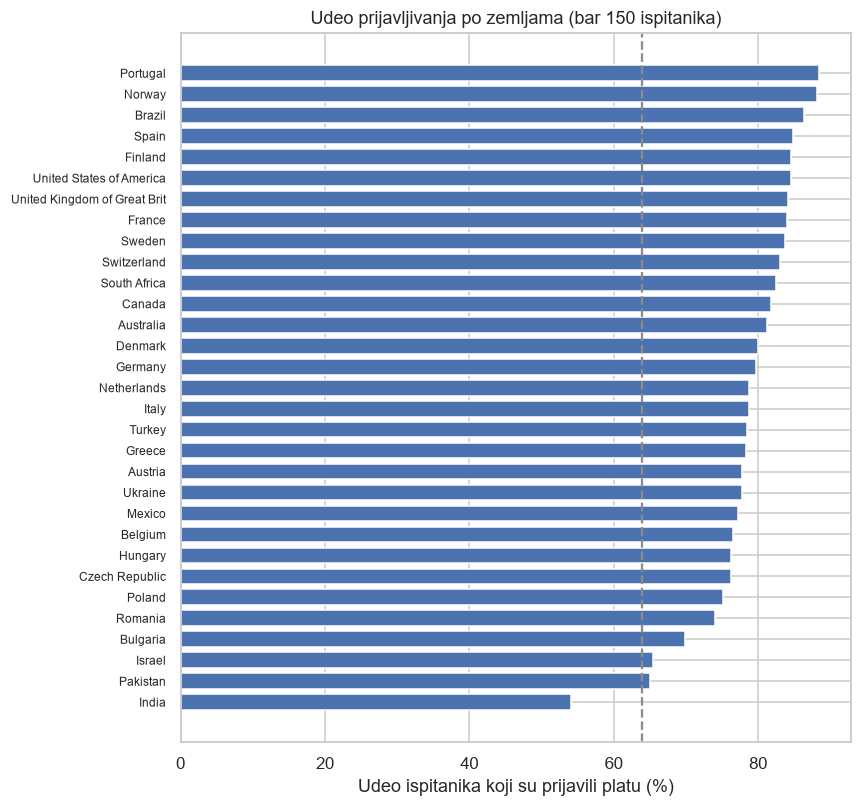

zemalja u prikazu: 31
najniži udeo:  54.0%  (India)
najviši udeo:  88.5%  (Portugal)
raspon:        34.5 procentnih poena
prosek grupe:  63.9%


In [15]:
by_country = completed.groupby("Country")["prijavio_platu"].agg(
    n="size", udeo=lambda s: 100 * s.mean()
)
by_country = by_country[by_country["n"] >= MIN_GROUP].sort_values("udeo")

fig, ax = plt.subplots(figsize=(8, 7.5))
ax.barh(range(len(by_country)), by_country["udeo"], color="#4C72B0", height=0.75)
ax.axvline(100 * completed["prijavio_platu"].mean(), color="#8C8C8C",
           linestyle="--", linewidth=1.5)

ax.set_yticks(range(len(by_country)))
ax.set_yticklabels([c[:28] for c in by_country.index], fontsize=8)
ax.set_xlabel("Udeo ispitanika koji su prijavili platu (%)")
ax.set_ylabel("")
ax.set_title(f"Udeo prijavljivanja po zemljama (bar {MIN_GROUP} ispitanika)")
plt.tight_layout()
plt.show()

print(f"zemalja u prikazu: {len(by_country)}")
print(f"najniži udeo:  {by_country['udeo'].min():.1f}%  ({by_country.index[0]})")
print(f"najviši udeo:  {by_country['udeo'].max():.1f}%  ({by_country.index[-1]})")
print(f"raspon:        {by_country['udeo'].max() - by_country['udeo'].min():.1f} procentnih poena")
print(f"prosek grupe:  {100 * completed['prijavio_platu'].mean():.1f}%")

**Zapažanje:** Razlika je velika. Udeo ide od **54,0% u Indiji do 88,5% u Portugalu** — raspon od
**34,5 procentnih poena**, uz prosek grupe od 63,9%. Indija je i ubedljivo najbrojnija među zemljama
sa niskim udelom.

**Tumačenje:** Ovo daleko prevazilazi prag od 10 procentnih poena koji smo postavili. Spremnost da se
plata prijavi očigledno zavisi od zemlje, i to snažno.

Zašto je tako, iz ovih podataka ne možemo da zaključimo — verovatno se meša nekoliko stvari, od toga
koliko se u nekoj sredini smatra pristojnim govoriti o plati, do toga koliko ispitanik veruje da će
podatak ostati anoniman. Za nas je bitna posledica, ne uzrok.

Ostaje da proverimo da li je razlika statistički značajna i kolika je zapravo, pa da vidimo da li se
isto ponaša i neko obeležje koje nije kategorijsko.

In [16]:
from scipy import stats

# Chi-square tests whether two categorical variables are independent; here,
# country and whether the salary was reported. Cramer's V rescales it to 0-1
# so the size of the association does not depend on the sample size.
country_subset = completed[completed["Country"].isin(by_country.index)]
contingency = pd.crosstab(country_subset["Country"], country_subset["prijavio_platu"])

chi2, p_value, dof, _ = stats.chi2_contingency(contingency)
n_test = contingency.to_numpy().sum()
cramers_v = np.sqrt(chi2 / (n_test * (min(contingency.shape) - 1)))

print(f"ispitanika u testu: {n_test:,}   zemalja: {len(contingency)}")
print(f"hi-kvadrat: {chi2:.1f}   stepeni slobode: {dof}   p = {p_value:.3g}")
print(f"Cramerovo V: {cramers_v:.3f}")

ispitanika u testu: 19,258   zemalja: 31
hi-kvadrat: 867.2   stepeni slobode: 30   p = 4.82e-163
Cramerovo V: 0.212


**Zapažanje:** P-vrednost je reda **10⁻¹⁶³**, dakle daleko ispod praga od 0,05. Cramerovo V iznosi
**0,212**.

**Tumačenje:** Hi-kvadrat test proverava da li su dve kategorijske promenljive nezavisne. Nismo ga
radili na predavanjima — koristimo ga jer nam je ovde poređenje između trideset i jedne zemlje, pa
t-test, koji poredi dve grupe, nije primenljiv. Cramerovo V uz njega služi da izmerimo **koliko je
veza jaka**, jer p-vrednost to ne govori.

Ta razlika je ovde ključna. Pri 19.258 ispitanika i najsitnija razlika bi ispala „statistički
značajna", pa nam p-vrednost sama po sebi ne znači mnogo. Vrednost V od 0,212 na skali od 0 do 1 je
umerena, i uz raspon od 34,5 procentnih poena potvrđuje da je veza i praktično bitna, ne samo
statistički.

Do sada smo gledali samo kategorijska obeležja, i merili ih razmakom udela između kategorija i
Cramerovim V. Ostaje da proverimo i jedno **neprekidno**: da li se **godine radnog staža** razlikuju
između onih koji su prijavili platu i onih koji nisu. Razmak udela tu nije primenljiv, jer staž nema
kategorije, pa koristimo t-test za razliku dve sredine i Cohenovo d za veličinu te razlike.

In [17]:
with_exp = completed.dropna(subset=["WorkExp"])
reported_exp = with_exp.loc[with_exp["prijavio_platu"], "WorkExp"]
silent_exp = with_exp.loc[~with_exp["prijavio_platu"], "WorkExp"]

t_stat, p_exp = stats.ttest_ind(reported_exp, silent_exp, equal_var=False)

# Cohen's d expresses the gap in standard deviations, so it does not grow with n.
pooled_sd = np.sqrt(
    ((len(reported_exp) - 1) * reported_exp.var() + (len(silent_exp) - 1) * silent_exp.var())
    / (len(reported_exp) + len(silent_exp) - 2)
)
cohens_d = (reported_exp.mean() - silent_exp.mean()) / pooled_sd

print(f"ispitanika u testu: {len(with_exp):,}")
print(f"  prijavili platu:  n={len(reported_exp):>6,}  sredina={reported_exp.mean():.2f} god.")
print(f"  nisu prijavili:   n={len(silent_exp):>6,}  sredina={silent_exp.mean():.2f} god.")
print()
print(f"razlika sredina: {reported_exp.mean() - silent_exp.mean():.2f} godine")
print(f"t-test:          t={t_stat:.2f}   p={p_exp:.3g}")
print(f"Cohenovo d:      {cohens_d:.3f}")

ispitanika u testu: 27,408
  prijavili platu:  n=17,683  sredina=12.98 god.
  nisu prijavili:   n= 9,725  sredina=12.43 god.

razlika sredina: 0.55 godine
t-test:          t=4.55   p=5.45e-06
Cohenovo d:      0.058


**Zapažanje:** Oni koji su prijavili platu imaju u proseku **12,98 godina** radnog staža, a oni koji
nisu **12,43** — razlika je **0,55 godine**. T-test daje p od **5,45 × 10⁻⁶**, dakle jasno ispod praga
od 0,05. Cohenovo d iznosi **0,058**.

**Tumačenje:** Ovo je primer koji vredi zapamtiti. Razlika **jeste statistički značajna**, ali je
**praktično zanemarljiva**. Pola godine staža na proseku od trinaest godina ne govori ništa korisno ni
o jednom ispitaniku, a Cohenovo d od 0,058 znači da su dve raspodele gotovo potpuno iste — kao mera
veličine efekta, sve ispod 0,2 se smatra malim.

Do značajnosti je došlo isključivo zato što imamo 27.408 ispitanika. Sa dovoljno velikim uzorkom p-
vrednost postaje mala i kod razlika koje nikoga ne zanimaju, i baš zato smo uz nju od početka tražili
i veličinu efekta.

Za samu hipotezu ovo znači da **godine staža nisu izvor problema**. Problem je zemlja.

### Šta brisanje konkretno radi uzorku

Znamo da udeo prijavljivanja zavisi od zemlje. Ako sad izbacimo sve koji nisu prijavili platu, iz
uzorka će nesrazmerno više nestati ljudi iz zemalja sa niskim udelom. Da vidimo koliko se brisanjem redova bez prijavljene plate menja sastav uzorka po zemljama.

In [18]:
share_before = population["Country"].value_counts(normalize=True) * 100
share_after = population.loc[population["prijavio_platu"], "Country"].value_counts(
    normalize=True) * 100

composition = pd.DataFrame({
    "n_pre": population["Country"].value_counts(),
    "udeo_pre_%": share_before,
    "udeo_posle_%": share_after,
}).dropna()
composition["promena_pp"] = composition["udeo_posle_%"] - composition["udeo_pre_%"]
composition = composition[composition["n_pre"] >= MIN_GROUP].sort_values("promena_pp")

print("najveći pad i najveći rast udela u uzorku:")
print(pd.concat([composition.head(3), composition.tail(3)]).round(2).to_string())

najveći pad i najveći rast udela u uzorku:
                                                      n_pre  udeo_pre_%  udeo_posle_%  promena_pp
Country                                                                                          
India                                                  1690        6.68          4.62       -2.06
Israel                                                  236        0.93          0.78       -0.15
Pakistan                                                174        0.69          0.58       -0.11
Brazil                                                  604        2.39          2.68        0.29
United Kingdom of Great Britain and Northern Ireland   1520        6.01          6.38        0.37
United States of America                               5107       20.20         21.67        1.47


**Zapažanje:** Indija sa **6,68% pada na 4,62%** udela u uzorku, dakle gubi 2,06 procentnih poena.
Sjedinjene Države istovremeno rastu sa **20,20% na 21,67%**.

**Tumačenje:** Brisanje nam pomera uzorak ka bogatijim zemljama. Pošto je zemlja jedan od najjačih
prediktora plate, to nije sporedna posledica — uzorak na kome ćemo trenirati model sistematski
precenjuje udeo dobro plaćenih tržišta u odnosu na populaciju ispitanika sa kojom smo krenuli.

## Verdikt

**Hipoteza je potvrđena.** Nedostajanje plate zavisi od posmatranih obeležja, i to ne samo od jednog:

- pregled svih 32 kategorijske kolone pokazao je razmak preko praga od 10 procentnih poena kod
  **zemlje (34,5), veličine firme (27,5), `SODuration` (26,7), `LearnCodeChoose` (21,1), `DevType`
  (19,6), `LanguageChoice` (15,2), načina rada (14,4) i starosti (13,2)**;
- kod zemlje, koju smo razradili do kraja, hi-kvadrat test daje p reda **10⁻¹⁶³** uz Cramerovo V od
  **0,212**, dakle veza je i statistički značajna i praktično umerena;
- godine staža, nasuprot tome, razlikuju se za svega **0,55 godine**, sa Cohenovim d od **0,058** —
  značajno, ali zanemarljivo. Nije, dakle, sve povezano sa nedostajanjem.

**Nedostajanje sigurno nije MCAR.** Brisanje redova bez prijavljene plate nije bezbedno u smislu u kom
smo to učili na predavanjima — ono menja sastav uzorka.

Da li je posredi MAR ili MNAR, **ne možemo da utvrdimo**, i to nije nedostatak analize nego granica
onoga što se iz ovakvih podataka može znati. Da bismo dokazali MNAR, trebalo bi da uporedimo plate
onih koji su ih prijavili sa platama onih koji nisu — a upravo te druge nemamo.

**Posledica po dalji rad.** Ipak nastavljamo sa brisanjem, iz razloga koji smo naveli na početku
sekcije: ciljna promenljiva se ne sme izmišljati, pa druge mogućnosti nemamo. Ali uz to idu dve
obaveze:

1. **Obeležja od kojih nedostajanje zavisi moraju da uđu u model** — pre svega zemlja, ali i veličina
   firme i način rada. Ako model zna iz koje je zemlje ispitanik i u kakvoj firmi radi, deo
   pristrasnosti koju brisanje unosi se time nadoknađuje. To je razlika između MAR-a koji je uzet u
   obzir i MAR-a koji je prećutan.
2. **U zaključku rada ovo se navodi kao ograničenje.** Model je treniran na uzorku u kome su
   ispitanici iz Indije potcenjeni, a iz Sjedinjenih Država precenjeni u odnosu na polazni skup.

## 3. Duplikati

Sada prelazimo na četiri koraka čišćenja onim redom kojim smo ih učili: duplikati, strukturne greške,
netipične vrednosti, nedostajuće vrednosti.

Kod ankete duplikat bi značio da je isti ispitanik popunio upitnik dva puta. To se ne bi videlo kroz
`ResponseId`, jer se on dodeljuje svakom slanju posebno — pa gledamo i da li postoje redovi koji se
poklapaju u **svim odgovorima**, a razlikuju se samo po tom identifikatoru.

In [19]:
# Everything except the identifier and the two flags we derived ourselves.
ANSWER_COLUMNS = [c for c in population.columns
                  if c not in ("ResponseId", "prijavio_platu", "prekinuo_anketu")]

print(f"redova u populaciji:              {len(population):>7,}")
print(f"potpuno identičnih redova:        {population.duplicated().sum():>7,}")
print(f"ponovljenih ResponseId:           {population['ResponseId'].duplicated().sum():>7,}")
print(f"identičnih po svim odgovorima:    "
      f"{population.duplicated(subset=ANSWER_COLUMNS).sum():>7,}")

redova u populaciji:               34,106


potpuno identičnih redova:              0
ponovljenih ResponseId:                 0


identičnih po svim odgovorima:        565


**Zapažanje:** Potpuno identičnih redova nema, niti ima ponovljenih `ResponseId`. Ali kada
identifikator izuzmemo, **565 redova se poklapa sa nekim drugim redom u svim odgovorima**.

**Tumačenje:** To na prvi pogled izgleda kao da je 565 ljudi poslalo anketu dvaput. Pre nego što ih
izbacimo, gledamo o kakvim je redovima reč — jer ako neko odgovori na svega nekoliko pitanja,
poklapanje sa nekim drugim takvim ispitanikom nije nikakvo iznenađenje.

In [20]:
# keep=False marks every row that takes part in a duplicate group, not just the repeats.
in_duplicate_group = population.duplicated(subset=ANSWER_COLUMNS, keep=False)
duplicates = population[in_duplicate_group].copy()
duplicates["popunjenih_odgovora"] = duplicates[ANSWER_COLUMNS].notna().sum(axis=1)

print(f"redova u duplikat-grupama: {len(duplicates):,}   od ukupno {len(ANSWER_COLUMNS)} kolona")
print()
print("koliko su ti redovi popunjeni:")
print(duplicates["popunjenih_odgovora"].describe()[["min", "50%", "max"]].round(1).to_string())
print()
print(f"od njih prijavilo platu: {duplicates['prijavio_platu'].sum()}")
print(f"prosečna popunjenost ostalih redova: "
      f"{population.loc[~in_duplicate_group, ANSWER_COLUMNS].notna().sum(axis=1).mean():.1f}")

redova u duplikat-grupama: 741   od ukupno 169 kolona

koliko su ti redovi popunjeni:
min    3.0
50%    5.0
max    9.0

od njih prijavilo platu: 0
prosečna popunjenost ostalih redova: 88.1


**Zapažanje:** U duplikat-grupama je **741 red**, i svi su gotovo prazni — imaju između **3 i 9
popunjenih odgovora od 169 kolona**, sa medijanom od 5. Ostali redovi u populaciji imaju u proseku
**88,1** popunjenih odgovora. **Nijedan od njih nema prijavljenu platu.**

**Tumačenje:** To nisu ljudi koji su anketu poslali dvaput, nego ljudi koji su je napustili posle
nekoliko prvih pitanja. Kad su popunjena samo tri do devet polja, i to uglavnom osnovna demografija,
poklapanje sa nekim drugim ispitanikom je očekivano — nema dovoljno odgovora da bi se dva čoveka
razlikovala.

Za nas to znači da **pravih duplikata nema**, i da ništa po ovom osnovu ne izbacujemo. Ovi redovi
ionako ispadaju iz uzorka jer nemaju ciljnu promenljivu, a to je odluka koju smo doneli u prethodnoj
sekciji, iz drugog razloga.

Vredi ipak zabeležiti da se ista grupa ljudi — oni koji su prekinuli anketu na početku — pojavljuje
već treći put: kod praznog `Employment`, kod prekinute ankete, i sada ovde. Pri obradi nedostajućih
vrednosti treba imati na umu da je jedan deo praznina u podacima posledica napuštanja upitnika, a ne
odbijanja pojedinačnog pitanja.

## 4. Strukturne greške

Strukturna greška je vrednost koja **postoji, ali je neispravna** — bilo zato što je pogrešno
zapisana, bilo zato što je logički nemoguća. Razlikuje se od druga dva problema koja obrađujemo:

| | Šta je | Po čemu se prepoznaje |
| --- | --- | --- |
| Nedostajuća vrednost | polje je prazno | vrednost je `NaN` |
| **Strukturna greška** | vrednost postoji ali je neispravna | pravilo koje znamo o toj koloni |
| Netipična vrednost | vrednost je ispravna ali ekstremna | raspodela — kvartili i IQR |

Zato strukturne greške idu **pre** netipičnih vrednosti. Ako ih ostavimo, one ulaze u račun kvartila i
pomeraju granicu po kojoj kasnije sudimo šta je ekstremno.

Kolona ima 172 — 170 iz ankete i dve koje smo dodali u sekciji 1 — i ne možemo ih sve pregledati
ručno. Ali svaka provera koju možemo da smislimo spada u
jednu od dve grupe, i to nam rešava problem izbora:

- **provere koje ne traže da znamo šta kolona znači** — kontrolni karakteri, prazan string umesto
  `NA`, kolona sa jednom jedinom vrednošću. Njih puštamo nad svim kolonama odjednom.
- **provere koje traže poznavanje kolone** — da li je staž od sto godina moguć. Njih radimo samo tamo
  gde imamo pravilo po kom sudimo.

Svaki problem obrađujemo do kraja pre nego što pređemo na sledeći: prvo ga izmerimo, pa ispravimo, pa
proverimo da ga više nema. Sve ispravke upisujemo u kopiju `cleaned`, da polazni skup ostane netaknut
za poređenje.

In [21]:
cleaned = population.copy()
text_columns = cleaned.select_dtypes(include="str").columns

print(f"kolona ukupno: {len(cleaned.columns)}   od toga tekstualnih: {len(text_columns)}")

kolona ukupno: 172   od toga tekstualnih: 119


### 4.1 Zapis u tekstualnim kolonama

Prva provera ne zahteva nikakvo znanje o kolonama: tražimo kontrolne karaktere (tab, prelom reda),
višak razmaka na krajevima, i prazne stringove koji su zapravo nedostajuće vrednosti.

In [22]:
def count_where(columns, predicate):
    """Per column, how many values satisfy the predicate; only non-zero counts."""
    counts = {c: int(predicate(cleaned[c].dropna().astype(str))) for c in columns}
    return {c: n for c, n in counts.items() if n > 0}


control_chars = count_where(text_columns, lambda s: s.str.contains("\t|\n|\r").sum())
stray_spaces = count_where(text_columns, lambda s: (s != s.str.strip()).sum())
empty_strings = count_where(text_columns, lambda s: (s.str.strip() == "").sum())

print(f"kolone sa kontrolnim karakterom: {control_chars}")
print(f"kolone sa viškom razmaka:        {stray_spaces}")
print(f"kolone sa praznim stringom:      {empty_strings}")

kolone sa kontrolnim karakterom: {'Currency': 6111, 'AIExplain': 323, 'AIOpen': 1000}
kolone sa viškom razmaka:        {'AIExplain': 88, 'AIOpen': 196}
kolone sa praznim stringom:      {'AIOpen': 1}


**Zapažanje:** Pogođene su tri kolone. **`Currency` sadrži tab karakter u 6.111 vrednosti** — vrednost
izgleda kao `'AUD\tAustralian dollar'` umesto `'AUD Australian dollar'`, kako je zapisano kod ostalih
valuta. `AIExplain` i `AIOpen` imaju prelome reda i višak razmaka.

**Tumačenje:** Kod `Currency` je to nedoslednost u zapisu koju moramo da ispravimo, jer bismo inače
istu valutu mogli tretirati kao dve različite kategorije. `AIExplain` i `AIOpen` su kolone sa
slobodnim tekstom, gde su prelomi očekivani jer ljudi kucaju rečenice. Njih normalizujemo iz istog
razloga kao i `Currency` — da provera bude potpuna i postupak dosledan — a da li kolone sa slobodnim
tekstom uopšte ulaze u model, odlučuje se tek u odeljku 6.3.

Ispravka je jednostavna: svaki niz belina svodimo na jedan razmak, a ono što posle toga ostane prazno
postaje `NA`.

In [23]:
for column in text_columns:
    # A regex replace keeps the string dtype, which .str.split().str.join() would
    # silently turn into a generic object column.
    normalised = cleaned[column].str.replace(r"\s+", " ", regex=True).str.strip()
    cleaned[column] = normalised.mask(normalised == "")

print("posle ispravke:")
print(f"  kolone sa kontrolnim karakterom: "
      f"{count_where(text_columns, lambda s: s.str.contains(chr(9) + '|' + chr(10)).sum())}")
print(f"  kolone sa viškom razmaka:        "
      f"{count_where(text_columns, lambda s: (s != s.str.strip()).sum())}")
print(f"  kolone sa praznim stringom:      "
      f"{count_where(text_columns, lambda s: (s.str.strip() == '').sum())}")
print()
print(f"primer vrednosti iz Currency: {cleaned['Currency'].dropna().iloc[0]!r}")
print(f"tip kolone Currency je i dalje: {cleaned['Currency'].dtype}")

posle ispravke:


  kolone sa kontrolnim karakterom: {}


  kolone sa viškom razmaka:        {}


  kolone sa praznim stringom:      {}

primer vrednosti iz Currency: 'EUR European Euro'
tip kolone Currency je i dalje: str


Sve tri provere sada vraćaju prazne rečnike, a vrednost u `Currency` je uredna.

### 4.2 Odgovori koji ne govore ništa o ispitaniku

Anketa na nekim pitanjima nudi odgovor tipa „radije ne bih rekao". To formalno jeste odgovor, ali ako
nam ne govori ništa o samom ispitaniku, ponaša se kao nedostajuća vrednost — a ako ga ostavimo kao
kategoriju, model bi mu dodelio koeficijent kao da je to neka vrsta uzrasta ili veličine firme.

Problem je što ne znamo unapred kako su takvi odgovori tačno formulisani. Nagađanje bi nas skupo
koštalo: dovoljno je da anketa koristi drugačiji apostrof ili malo drugačiju formulaciju pa da nam
stotine vrednosti promaknu. Zato **ne pišemo listu iz glave**, nego pretražujemo sve kategorijske
kolone i tražimo vrednosti koje liče na odbijanje odgovora.

In [24]:
import re

# Deliberately broad: we would rather look at a few false positives than miss a
# phrasing we did not think of.
NON_ANSWER_PATTERN = r"prefer not|rather not|don.t know|do not know|not sure|unsure"

candidates = []
for column in text_columns:
    values = cleaned[column]
    # Free-text columns have thousands of distinct answers and are not categories.
    if values.nunique(dropna=True) > 200:
        continue
    for value in values.dropna().unique():
        if len(value) < 60 and re.search(NON_ANSWER_PATTERN, value, re.IGNORECASE):
            candidates.append({
                "kolona": column,
                "vrednost": value,
                "pojavljivanja": int((values == value).sum()),
            })

found = pd.DataFrame(candidates).sort_values("pojavljivanja", ascending=False)
print(found[found["pojavljivanja"] >= 50].to_string(index=False))

   kolona                                              vrednost  pojavljivanja
 AIThreat                                          I'm not sure           5473
AIComplex I don't use AI tools for complex tasks / I don't know           3629
SOAccount                               Not sure/can't remember           1428
  OrgSize                                          I don’t know            535
   AISent                                                Unsure            399
   SOComm                                              Not sure            161
      Age                                     Prefer not to say             92


**Zapažanje:** Pronađeno je sedam vrednosti sa preko pedeset pojavljivanja, svaka u drugoj koloni.
Ubedljivo najbrojnija je `„I'm not sure"` u koloni `AIThreat`, sa **5.473 ispitanika**, zatim
`„I don't use AI tools for complex tasks / I don't know"` u `AIComplex` sa **3.629**,
`„Not sure/can't remember"` u `SOAccount` sa **1.428**, pa `„I don't know"` u `OrgSize` sa **535**.

**Tumačenje:** Lista pokazuje da se tu kriju **dve različite stvari**, i da ih ne smemo tretirati isto.

Kod nekih pitanja odgovor prikriva osobinu koju ispitanik sigurno ima. Svako ima godine, i svaka firma
ima neki broj zaposlenih — kada neko na to odgovori sa „radije ne bih rekao" ili „ne znam", osobina
postoji, mi je samo ne saznajemo. To je nedostajuća vrednost i tako je i tretiramo.

Kod drugih pitanja nesigurnost **jeste odgovor**. Na pitanje da li veruje da mu AI ugrožava posao,
`„I'm not sure"` stoji kao ravnopravna mogućnost pored „da" i „ne" — to je stav ispitanika, a ne
podatak koji nam nedostaje. Isto važi za `AISent`, gde je `„Unsure"` jedna od kategorija stava, za
`AIComplex`, gde odgovor počinje rečima „ne koristim AI alate za složene zadatke", i za `SOComm`, gde
uz „Not sure" postoji i zasebna kategorija „Neutral".

Da smo listu napisali napamet, ovu razliku ne bismo ni videli. Usput bismo promašili i `OrgSize`, gde
je apostrof u „I don't know" tipografski, a ne onaj sa tastature — 535 vrednosti koje bi ostale
neprimećene.

In [25]:
# Only where the answer hides an attribute the respondent certainly has.
HIDDEN_ATTRIBUTE = {
    "Age": ["Prefer not to say"],
    "OrgSize": ["I don’t know"],
}

for column, values in HIDDEN_ATTRIBUTE.items():
    affected = cleaned[column].isin(values)
    missing_before = 100 * cleaned[column].isna().mean()
    cleaned.loc[affected, column] = np.nan
    print(f"{column:<9} poništeno {int(affected.sum()):>4} vrednosti   "
          f"nedostaje {missing_before:.1f}% -> {100 * cleaned[column].isna().mean():.1f}%")

print()
still_there = {c: int(cleaned[c].isin(v).sum()) for c, v in HIDDEN_ATTRIBUTE.items()}
print(f"preostalo posle ispravke: {still_there}")
print(f"AIThreat i dalje ima kategoriju \"I'm not sure\": "
      f"{int((cleaned['AIThreat'] == chr(73) + chr(39) + 'm not sure').sum()):,} ispitanika")

Age       poništeno   92 vrednosti   nedostaje 0.0% -> 0.3%
OrgSize   poništeno  535 vrednosti   nedostaje 18.2% -> 19.8%

preostalo posle ispravke: {'Age': 0, 'OrgSize': 0}
AIThreat i dalje ima kategoriju "I'm not sure": 5,473 ispitanika


**Zapažanje:** Poništene su 92 vrednosti u `Age` i 535 u `OrgSize`. Kategorija `„I'm not sure"` u
`AIThreat` je netaknuta.

**Tumačenje:** `Age` nam je posebno bitna jer ćemo je u odeljku 4.4 koristiti da postavimo granicu
koliko je neko uopšte mogao da radi. Ako je uzrast nepoznat, ta granica se ne može izračunati — a to je
ispravno, jer za takvog ispitanika zaista ne znamo da li mu je staž moguć ili nije. Da smo „Prefer not
to say" ostavili kao kategoriju, granica bi se računala nad besmislenom vrednošću.

### 4.3 Kolone bez ijedne varijacije

Kolona koja u celom skupu ima samo jednu vrednost ne razlikuje nijednog ispitanika od drugog, pa u
modelu ne može ništa da doprinese.

In [26]:
constant = [c for c in cleaned.columns if cleaned[c].nunique(dropna=True) <= 1]
print(f"konstantne kolone: {constant}")
print(f"jedina vrednost u MainBranch: {cleaned['MainBranch'].dropna().unique()}")

konstantne kolone: ['MainBranch']
jedina vrednost u MainBranch: <StringArray>
['I am a developer by profession']
Length: 1, dtype: str


**Zapažanje:** Konstantna je jedna jedina kolona — **`MainBranch`**, sa jedinom vrednošću „I am a
developer by profession".

**Tumačenje:** To je posledica našeg sopstvenog rada. Populaciju smo u sekciji 1 suzili baš po toj
koloni, pa ona sada nema nikakvu varijaciju.

Kolonu ovde ne brišemo — brisanje kolona radimo na jednom mestu, u sekciji 6, po jedinstvenom skupu
kriterijuma. Ovde je samo beležimo.

### 4.4 Nemoguće vrednosti u kolonama koje razumemo

Sada prelazimo na drugu vrstu provera, one koje traže da znamo šta kolona meri. Numeričkih kolona ima
51, ali one nisu iste vrste:

- **sedam kolona** meri veličine sa jasnim značenjem — dve o iskustvu, dve o kompenzaciji, jedna o
  zadovoljstvu poslom i dve o broju alata. Za njih možemo da postavimo pravilo šta je moguće.
- **preostale 43** su odgovori na pitanja tipa „poređaj po važnosti", koje ćemo obraditi zasebno u
  odeljku 4.5, jer se kod njih pravilo ispravnosti postavlja drugačije.
- `ResponseId` je identifikator i ne meri ništa.

Počinjemo od opsega kod prvih sedam.

In [27]:
# Numeric columns whose meaning we know well enough to state a rule for.
CHECKED_NUMERIC = ["WorkExp", "YearsCode", "CompTotal", "ConvertedCompYearly",
                   "JobSat", "ToolCountWork", "ToolCountPersonal"]

ranges = cleaned[CHECKED_NUMERIC].agg(["min", "max"]).T
ranges["nedostaje_%"] = (100 * cleaned[CHECKED_NUMERIC].isna().mean()).round(1)
print(ranges.to_string())

                     min           max  nedostaje_%
WorkExp              1.0  1.000000e+02          3.8
YearsCode            1.0  1.000000e+02          9.1
CompTotal            0.0  1.000000e+23         42.4
ConvertedCompYearly  1.0  3.355272e+07         42.9
JobSat               0.0  1.000000e+01         26.9
ToolCountWork        0.0  1.000000e+04         40.0
ToolCountPersonal    0.0  1.000000e+03         47.0


**Zapažanje:** `WorkExp` i `YearsCode` idu **do 100**. `CompTotal` ima maksimum od **10²³**, a
minimum **0**. `ToolCountWork` ide do **10.000**, `ToolCountPersonal` do **1.000**. `JobSat` je u
opsegu 0 do 10, što je uredno.

**Tumačenje:** Sto godina radnog staža nije moguće, iznos od 10²³ dolara nije ni iznos, a deset hiljada
različitih programa koje neko redovno koristi na poslu nije realno.

Kod staža sam maksimum ne govori koliko je vrednosti sporno. Umesto da izmislimo granicu, koristimo
podatak koji već imamo — **uzrast ispitanika**. Za svaku starosnu kategoriju znamo gornju granicu, pa
oduzimanjem dobijamo koliko je neko najviše mogao da radi ili programira.

Granice moraju biti različite za dve kolone: profesionalni rad realno počinje oko osamnaeste, dok
`YearsCode` broji programiranje „uključujući obrazovanje", što može da počne i u detinjstvu.

In [28]:
# The upper bound of an age band is read out of its own label. Only the open
# ended top band needs a number of our own, and 80 is deliberately generous, so
# that it flags nobody who could plausibly have worked that long.
OPEN_BAND_CEILING = 80


def age_ceiling(label):
    """Highest age a respondent in this band can have."""
    numbers = [int(n) for n in re.findall(r"\d+", label)]
    if len(numbers) > 1:                      # closed band, e.g. "25-34 years old"
        return max(numbers)
    if label.lower().startswith("under"):     # "Under 18 years old"
        return numbers[0]
    return OPEN_BAND_CEILING                  # "65 years or older"


# One ceiling per age band that actually occurs in the data.
AGE_CEILING = {band: age_ceiling(band) for band in sorted(cleaned["Age"].dropna().unique())}
print(f"starosnih kategorija u podacima: {len(AGE_CEILING)}")
for band, ceiling in AGE_CEILING.items():
    print(f"  {band:<20} najviše {ceiling} godina")
print()

oldest_age = cleaned["Age"].map(AGE_CEILING)
impossible_work = cleaned["WorkExp"] > (oldest_age - 18)
impossible_code = cleaned["YearsCode"] > (oldest_age - 8)

print(f"WorkExp iznad granice za uzrast:   {impossible_work.sum():>4}")
print(f"YearsCode iznad granice za uzrast: {impossible_code.sum():>4}")
print()
print("WorkExp, po starosnim kategorijama:")
print(cleaned[impossible_work].groupby("Age", observed=True)["WorkExp"]
      .agg(redova="size", najveca="max").to_string())
print()
print(f"vrednost tačno 100 kod WorkExp:   {(cleaned['WorkExp'] == 100).sum():>4}")
print(f"vrednost tačno 100 kod YearsCode: {(cleaned['YearsCode'] == 100).sum():>4}")

# The two starting ages are a judgement call, so we check how much the result
# depends on them.
for work_start, code_start in [(16, 6), (18, 8), (20, 10)]:
    n_work = (cleaned["WorkExp"] > (oldest_age - work_start)).sum()
    n_code = (cleaned["YearsCode"] > (oldest_age - code_start)).sum()
    print(f"  početak rada sa {work_start}, programiranja sa {code_start}: "
          f"WorkExp {n_work:>4}, YearsCode {n_code:>4}")

starosnih kategorija u podacima: 6
  18-24 years old      najviše 24 godina
  25-34 years old      najviše 34 godina
  35-44 years old      najviše 44 godina
  45-54 years old      najviše 54 godina
  55-64 years old      najviše 64 godina
  65 years or older    najviše 80 godina

WorkExp iznad granice za uzrast:    324
YearsCode iznad granice za uzrast:   61

WorkExp, po starosnim kategorijama:
                   redova  najveca
Age                               
18-24 years old       133    100.0
25-34 years old        79    100.0
35-44 years old        65    100.0
45-54 years old        34    100.0
55-64 years old        12    100.0
65 years or older       1     65.0

vrednost tačno 100 kod WorkExp:      9
vrednost tačno 100 kod YearsCode:   11
  početak rada sa 16, programiranja sa 6: WorkExp  138, YearsCode   28
  početak rada sa 18, programiranja sa 8: WorkExp  324, YearsCode   61
  početak rada sa 20, programiranja sa 10: WorkExp 1363, YearsCode  301


**Zapažanje:** Granice prema uzrastu izdvajaju **324 reda kod `WorkExp`** i **61 kod `YearsCode`**.
Najbrojnija je kategorija 18–24 godine, sa 133 reda. U pet od šest starosnih kategorija najveća
prijavljena vrednost je **tačno 100**; izuzetak je kategorija 65 i više, u kojoj je izdvojen samo
jedan red, sa 65 godina staža. Vrednost tačno 100 javlja se 9 puta kod `WorkExp` i 11 puta kod
`YearsCode`.

Poslednja tri reda ispisa pokazuju koliko rezultat zavisi od toga koje smo početne godine izabrali.
Ako rad pomerimo na šesnaestu, broj spornih redova pada na 138; ako ga pomerimo na dvadesetu, skoči na
1.363.

**Tumačenje:** To što se maksimum u gotovo svakoj kategoriji zaustavlja baš na okrugloj stotini nije
slučajnost. Ili je 100 gornja granica polja u anketi, ili tako popunjavaju oni koji ne odgovaraju
ozbiljno. U svakom slučaju, osoba od 22 godine sa sto godina staža nije netipičan ispitanik nego
neispravan podatak.

Provera osetljivosti pokazuje da izbor početnih godina **nije nebitan** — sa dvadesetom kao početkom
rada dobili bismo četiri puta više spornih redova. Zato biramo osamnaestu, koja je najbliža stvarnom
početku radnog veka, i time namerno grešimo u korist ispitanika: označavamo samo one slučajeve koji su
nemogući i pod najblažom pretpostavkom. Isto važi za osmu godinu kod programiranja.

Ostali izdvojeni redovi nisu tako drastični, ali su i dalje nemogući — trideset godina staža kod
osobe iz kategorije 18–24 ne postoji. Sve njih tretiramo isto.

In [29]:
cleaned.loc[impossible_work, "WorkExp"] = np.nan
cleaned.loc[impossible_code, "YearsCode"] = np.nan

print("posle ispravke:")
print(f"  WorkExp maksimum:   {cleaned['WorkExp'].max():>5.0f}   "
      f"nedostaje {100 * cleaned['WorkExp'].isna().mean():.1f}% "
      f"(pre: {100 * population['WorkExp'].isna().mean():.1f}%)")
print(f"  YearsCode maksimum: {cleaned['YearsCode'].max():>5.0f}   "
      f"nedostaje {100 * cleaned['YearsCode'].isna().mean():.1f}% "
      f"(pre: {100 * population['YearsCode'].isna().mean():.1f}%)")
print()
print(f"redova pre ispravke:  {len(population):,}")
print(f"redova posle:         {len(cleaned):,}")

posle ispravke:
  WorkExp maksimum:      60   nedostaje 4.7% (pre: 3.8%)
  YearsCode maksimum:    65   nedostaje 9.3% (pre: 9.1%)

redova pre ispravke:  34,106
redova posle:         34,106


**Zapažanje:** Maksimumi su sada 60 i 65 godina, a broj redova je nepromenjen — **34.106 pre i
posle**. Udeo nedostajućih vrednosti porastao je kod `WorkExp` sa **3,8% na 4,7%**, a kod `YearsCode` sa
**9,1% na 9,3%** — dakle za 0,9 odnosno 0,2 procentna poena.

**Tumačenje:** Nemoguće vrednosti **ne brišu ceo red**, nego samo tu jednu ćeliju. Ispitanik sa
pogrešno unetim stažom i dalje ima ispravnu platu, zemlju i sve ostalo; jedino njegov staž ne znamo.
Brisanjem celog reda bacili bismo ispravne podatke zbog jednog polja.

Zbog toga nedostajućih vrednosti sada ima više nego pre — i to je iskreniji zapis stanja. Staž od sto
godina tvrdio bi nešto što nije tačno, dok `NA` pošteno kaže da vrednost ne znamo.

**Ove `NA` vrednosti ovde ne popunjavamo.** Popunjavanje se radi imputacijom, u sekciji 9, i tek posle
podele na trening i test skup — jer svako popunjavanje koje računa prosek ili medijanu po grupi mora
da koristi isključivo trening podatke, inače bi test skup nosio informaciju o sebi.

Kod broja alata nemamo pravilo kao kod staža — ne postoji spoljni podatak iz kog bismo izveli
granicu. Zato prvo gledamo kako raspodela izgleda, pa granicu biramo prema onome što vidimo.

In [30]:
for column in ["ToolCountWork", "ToolCountPersonal"]:
    values = cleaned[column].dropna()
    print(column)
    print(values.describe(percentiles=[0.5, 0.9, 0.99]).round(1).to_string())
    large = values[values > 50].value_counts().sort_index()
    print(f"  vrednosti preko 50: {int(large.sum())}, "
          f"od toga na okruglim brojevima: "
          f"{int(large[large.index.isin([100, 500, 999, 1000, 9999, 10000])].sum())}")
    print(f"  deset najvećih vrednosti: {[int(v) for v in sorted(values.unique())[-10:]]}")
    print()

ToolCountWork
count    20461.0
mean        15.0
std        218.2
min          0.0
50%          6.0
90%         15.0
99%         50.0
max      10000.0
  vrednosti preko 50: 149, od toga na okruglim brojevima: 83
  deset najvećih vrednosti: [999, 1000, 1337, 1871, 2000, 2100, 4500, 5000, 9999, 10000]

ToolCountPersonal
count    18080.0
mean         7.9
std         39.0
min          0.0
50%          5.0
90%         11.0
99%         42.0
max       1000.0
  vrednosti preko 50: 110, od toga na okruglim brojevima: 61
  deset najvećih vrednosti: [223, 250, 255, 300, 400, 500, 512, 982, 999, 1000]



**Zapažanje:** Kod `ToolCountWork` je medijana **6**, deveti decil **15**, a 99. percentil **50** —
posle čega raspodela puca sve do **10.000**. Preko pedeset ima **149 vrednosti, od kojih su 83 na
okruglim brojevima** poput 100, 1.000 ili 10.000. Kod `ToolCountPersonal` je slika ista: 99. percentil
je **42**, a od **110** vrednosti preko pedeset njih **61** je okruglo.

**Tumačenje:** Raspodela je glatka do pedesetak alata, a posle toga se sastoji uglavnom od okruglih
brojeva. To nisu ljudi koji zaista koriste hiljadu programa, nego odgovori dati odoka ili u šali —
među njima ima i vrednosti poput 1337, 9999 i 10.000.

Granicu zato ne biramo napamet nego je uzimamo sa **99. percentila kolone `ToolCountWork`, dakle 50**.
Istu granicu primenjujemo i na `ToolCountPersonal`, iako je njen 99. percentil niži (42) — od dve
mogućnosti biramo blažu, da bismo poništili samo ono što je sporno po obe. Time gubimo oko procenat
najviših vrednosti, ali su to baš one koje raspodela ne podržava.

Pre nego što granicu primenimo, da vidimo kako taj prelom izgleda.

### Grafik 4 — raspodela broja alata

**Motivacija:** Percentili pokazuju gde je masa, ali ne i kako izgleda ono što je iznad nje. Crtamo
raspodelu da vidimo da li se visoke vrednosti postepeno proređuju ili se gomilaju na određenim
brojevima.

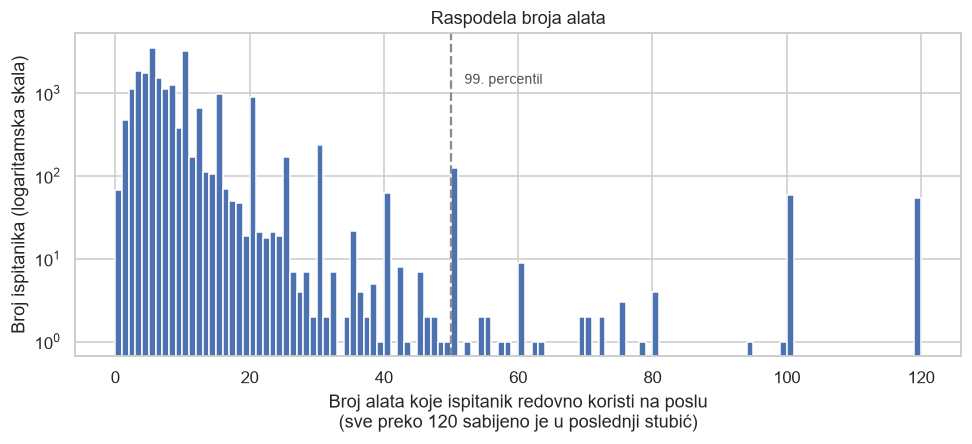

  vrednost tačno  50:  125 ispitanika
  vrednost tačno  60:    9 ispitanika
  vrednost tačno  80:    4 ispitanika
  vrednost tačno 100:   60 ispitanika
  vrednost tačno 120:    1 ispitanika


In [31]:
fig, ax = plt.subplots(figsize=(9, 4.2))

values = cleaned["ToolCountWork"].dropna()
ax.hist(np.clip(values, 0, 120), bins=120, color="#4C72B0")
ax.axvline(values.quantile(0.99), color="#8C8C8C", linestyle="--", linewidth=1.5)
ax.text(values.quantile(0.99) + 2, ax.get_ylim()[1] * 0.35,
        "99. percentil", color="#4C4C4C", fontsize=9)

ax.set_yscale("log")
ax.set_xlabel("Broj alata koje ispitanik redovno koristi na poslu\n"
              "(sve preko 120 sabijeno je u poslednji stubić)")
ax.set_ylabel("Broj ispitanika (logaritamska skala)")
ax.set_title("Raspodela broja alata")
plt.tight_layout()
plt.show()

for value in [50, 60, 80, 100, 120]:
    print(f"  vrednost tačno {value:>3}: {int((values == value).sum()):>4} ispitanika")

**Zapažanje:** Do pedesetak alata raspodela glatko opada. Posle toga se ne proređuje ravnomerno nego
skače na okruglim brojevima. Na vrednosti tačno **50** stoji **125 ispitanika**, a na tačno **100**
njih **60** — znatno više nego na susednim vrednostima, gde ih je po nekoliko.

**Tumačenje:** Taj oblik je potpis odgovora datog odoka. Ko stvarno broji alate ne završi baš na
okruglih sto, a ko ne broji nego procenjuje, bira okruglu vrednost. Granica sa 99. percentila pada
tačno tamo gde glatki deo raspodele prestaje, pa je grafik podržava.

In [32]:
# The 99th percentile of ToolCountWork, above which the distribution consists of
# round numbers only; the same, looser bound is applied to ToolCountPersonal.
TOOL_LIMIT = 50

for column in ["ToolCountWork", "ToolCountPersonal"]:
    suspicious = cleaned[column] > TOOL_LIMIT
    cleaned.loc[suspicious, column] = np.nan
    print(f"{column:<18} poništeno {int(suspicious.sum()):>4}   "
          f"novi maksimum: {cleaned[column].max():.0f}   "
          f"nedostaje {100 * cleaned[column].isna().mean():.1f}%")

print()
zero_or_less = cleaned["CompTotal"] <= 0
print(f"CompTotal <= 0: {int(zero_or_less.sum())},  od njih sa vrednošću u "
      f"ConvertedCompYearly: {int(cleaned.loc[zero_or_less, 'ConvertedCompYearly'].notna().sum())}")

ToolCountWork      poništeno  149   novi maksimum: 50   nedostaje 40.4%
ToolCountPersonal  poništeno  110   novi maksimum: 50   nedostaje 47.3%

CompTotal <= 0: 77,  od njih sa vrednošću u ConvertedCompYearly: 0


**Zapažanje:** Poništeno je **149 vrednosti kod `ToolCountWork` i 110 kod `ToolCountPersonal`**, i kod
obe je maksimum sada 50. Kod `CompTotal` je 77 redova sa nulom ili manje, i **nijedan od njih nema
vrednost u `ConvertedCompYearly`**.

**Tumačenje:** Poslednji nalaz je zanimljiv — Stack Overflow te iznose **već tretira kao neispravne**,
pa im nije ni izračunao dolarsku vrednost. To se slaže sa onim što smo utvrdili u prethodnom
notebook-u, da je konverzija dosledna. Pošto `CompTotal` ionako izbacujemo zbog curenja podataka, tu
ništa ne moramo da radimo.

### 4.5 Kolone sa rangiranjem

Preostale 43 numeričke kolone dolaze iz pitanja oblika „poređaj sledeće po važnosti" — `TechEndorse`,
`TechOppose`, `JobSatPoints` i `SO_Actions`. Svaka kolona nosi rang koji je ispitanik dodelio jednoj
stavci.

Kod njih nema smisla pitati da li je vrednost prevelika, jer ne znamo koliko je stavki ponuđeno. Ali
postoji drugo pravilo, koje sledi iz same prirode rangiranja: **isti ispitanik ne može dvema stavkama
dati isti rang.** Ako se to dogodi, odgovor je neispravan.

In [33]:
# Ranking questions export one column per item, named "<question>_<number>".
# We find those groups instead of listing them by hand.
numeric_columns = cleaned.select_dtypes(include="number").columns
groups = {}
for column in numeric_columns:
    match = re.fullmatch(r"(.+?)_(\d+)", column)
    if match:
        groups.setdefault(match.group(1), []).append(column)

rank_groups = {name: cols for name, cols in groups.items() if len(cols) >= 5}
print(f"pronađeno grupa sa rangiranjem: {len(rank_groups)}")
print()

for name, group in rank_groups.items():
    answers = cleaned[group]
    answered = answers.notna().any(axis=1)
    filled = answers[answered].notna().sum(axis=1)
    distinct = answers[answered].apply(lambda row: row.dropna().nunique(), axis=1)
    repeated = (filled != distinct)
    print(f"{name:<13} kolona={len(group):>2}   odgovorilo={int(answered.sum()):>6,}   "
          f"ponovljen rang kod {int(repeated.sum())} ispitanika")

pronađeno grupa sa rangiranjem: 4



TechEndorse   kolona=10   odgovorilo=25,845   ponovljen rang kod 0 ispitanika


TechOppose    kolona=10   odgovorilo=24,600   ponovljen rang kod 0 ispitanika


JobSatPoints  kolona=13   odgovorilo=23,364   ponovljen rang kod 0 ispitanika


SO_Actions    kolona=10   odgovorilo=18,945   ponovljen rang kod 0 ispitanika


**Zapažanje:** Ni u jednoj od četiri grupe **nema nijednog ispitanika koji je dva puta dodelio isti
rang**. Sve četiri provere vraćaju nulu.

**Tumačenje:** Te kolone su interno ispravne i nemamo šta da čistimo. To je i očekivano, jer anketni
softver obično sam ne dozvoljava dva ista ranga — ali dok se ne proveri, to je pretpostavka, a ne
podatak.

Ovim je i njih pokrilo isto pravilo kao i ostale kolone: proverili smo ih onom proverom koja za njihov
tip ima smisla. Da li ćemo ih koristiti kao promenljive je zasebno pitanje i rešava se u sekciji 6,
zajedno sa svim ostalim kolonama.

### Šta je sekcija promenila

Nijedan red nije izbačen — populacija je i dalje **34.106 ispitanika**. Promenjene su pojedinačne
vrednosti:

- beline i kontrolni karakteri normalizovani u svim tekstualnim kolonama, čime je `Currency` dobila
  dosledan zapis;
- odgovori koji prikrivaju postojeću osobinu pretvoreni u `NA` — 92 vrednosti u `Age` i 535 u
  `OrgSize`; nesigurnost koja je i sama odgovor, kao u `AIThreat` i `AISent`, zadržana je kao
  kategorija;
- nemoguć staž poništen u 324 reda kod `WorkExp` i 61 kod `YearsCode`;
- broj alata iznad 99. percentila poništen — 149 vrednosti kod `ToolCountWork` i 110 kod
  `ToolCountPersonal`;
- `MainBranch` zabeležena kao konstantna, `CompTotal` kao kolona sa besmislenim unosima — obe ispadaju
  u sekciji 6, iz drugih razloga;
- četiri grupe kolona sa rangiranjem proverene i ispravne.

Sada kada nemogućih vrednosti nema, kvartili i IQR računaju se nad ispravnim podacima, pa možemo da
pređemo na netipične vrednosti.

## 5. Hipoteza 4 — netipične vrednosti u ciljnoj promenljivoj

Do sada smo sklanjali vrednosti koje su **nemoguće**. Sada dolaze one koje su moguće ali ekstremne, i
tu se pravilo ne izvodi iz značenja kolone nego iz raspodele.

U prethodnom notebook-u smo videli da su problematična **oba kraja**: najmanja prijavljena kompenzacija
je jedan dolar, a najveća pedeset miliona. Logaritamska transformacija je sredila desni rep ali je
otkrila levi, pa ekstremi ostaju otvoreno pitanje.

Sa predavanja imamo dva postupka za traženje netipičnih vrednosti. Pravilo tri sigme i z-skor su
**parametarski** — pretpostavljaju normalnu raspodelu. Boxplot i IQR su **neparametarski** i ne
pretpostavljaju ništa o obliku. Pošto smo već pokazali da raspodela kompenzacije nije ni blizu
normalne, parametarski postupci otpadaju i radimo sa IQR-om.

Granice su uobičajene: sve ispod `Q1 − 1,5 × IQR` i iznad `Q3 + 1,5 × IQR`.

Otvoreno je, međutim, **nad kojim skupom** te granice računamo — nad celim svetom odjednom ili unutar
svake zemlje posebno.

> **Hipoteza:** Granice se moraju računati unutar zemlje. Globalno pravilo, primenjeno na ceo uzorak
> odjednom, ne razlikuje neispravan podatak od uobičajene plate u siromašnijoj zemlji.
>
> **Kriterijum, postavljen unapred:** Hipoteza je potvrđena ako globalno pravilo pogađa zemlje krajnje
> neravnomerno — ako se udeo označenih u najpogođenijoj zemlji višestruko razlikuje od udela u
> najmanje pogođenoj. Ako je taj udeo približno isti svuda, pravilo hvata greške a ne siromašnija
> tržišta, i deljenje po zemljama nije potrebno.

In [34]:
target_rows = cleaned.dropna(subset=["ConvertedCompYearly"]).copy()
target_rows["log_comp"] = np.log10(target_rows["ConvertedCompYearly"])

print(f"ispitanika sa prijavljenom platom: {len(target_rows):,}")


def iqr_bounds(values):
    """Classic boxplot fences: 1.5 IQR below Q1 and above Q3."""
    q1, q3 = values.quantile(0.25), values.quantile(0.75)
    spread = q3 - q1
    return q1 - 1.5 * spread, q3 + 1.5 * spread


low, high = iqr_bounds(target_rows["ConvertedCompYearly"])
below = (target_rows["ConvertedCompYearly"] < low).sum()
above = (target_rows["ConvertedCompYearly"] > high).sum()

print()
print("IQR nad sirovim vrednostima:")
print(f"  donja granica: {low:>12,.0f} USD")
print(f"  gornja granica:{high:>12,.0f} USD")
print(f"  označeno ispod: {below:>5}    iznad: {above:>5}    "
      f"ukupno {100 * (below + above) / len(target_rows):.1f}%")

ispitanika sa prijavljenom platom: 19,461

IQR nad sirovim vrednostima:
  donja granica:      -77,370 USD
  gornja granica:     246,422 USD
  označeno ispod:     0    iznad:   853    ukupno 4.4%


**Zapažanje:** Donja granica ispada **negativna**, −**77.370** dolara. Zbog toga ispod nje ne pada
**nijedan** ispitanik, dok je iznad gornje granice označeno **853 njih**.

**Tumačenje:** Postupak je ovde beskoristan za polovinu problema. Raspodela je toliko iskošena udesno
da je razmak između kvartila veliki, pa donja granica sklizne ispod nule — a plata ne može biti
negativna. Ispitanik koji je prijavio jedan dolar godišnje prolazi kao sasvim uredan.

To nije mana IQR-a nego posledica toga što ga primenjujemo na pogrešnoj skali. Već smo odlučili da
ciljnu promenljivu modelujemo u logaritamskom obliku, pa je prirodno da i granice tražimo tamo — na
logaritamskoj skali raspodela je približno simetrična, što je ono na šta se boxplot i oslanja.

In [35]:
log_low, log_high = iqr_bounds(target_rows["log_comp"])
target_rows["globalno_netipican"] = (
    (target_rows["log_comp"] < log_low) | (target_rows["log_comp"] > log_high)
)

print("IQR nad logaritmovanim vrednostima:")
print(f"  donja granica: {10 ** log_low:>12,.0f} USD")
print(f"  gornja granica:{10 ** log_high:>12,.0f} USD")
print(f"  označeno ispod: {(target_rows['log_comp'] < log_low).sum():>5}    "
      f"iznad: {(target_rows['log_comp'] > log_high).sum():>5}    "
      f"ukupno {100 * target_rows['globalno_netipican'].mean():.1f}%")

IQR nad logaritmovanim vrednostima:
  donja granica:        9,216 USD
  gornja granica:     597,484 USD
  označeno ispod:  1581    iznad:   106    ukupno 8.7%


**Zapažanje:** Granice su sada **9.216 i 597.484 dolara**, i obe strane su u igri — ispod je označen
**1.581 ispitanik**, iznad **106**, ukupno **8,7%**.

**Tumačenje:** Postupak sada vidi i donji kraj, što je bio ceo problem sa sirovom skalom. Ali pre nego
što bilo šta izbacimo, vredi pogledati **ko** je time označen. Granica od 9.216 dolara je za nekoga u
Švajcarskoj nezamisliva, a za nekoga u Indiji sasvim uobičajena plata.

In [36]:
# For every country, how many of its respondents the global rule just marked.
flagged_by_country = target_rows.groupby("Country").agg(
    ispitanika=("log_comp", "size"),
    oznaceno_globalnim=("globalno_netipican", "sum"),
)
flagged_by_country["udeo_%"] = (
    100 * flagged_by_country["oznaceno_globalnim"] / flagged_by_country["ispitanika"]).round(1)
flagged_by_country = flagged_by_country[flagged_by_country["ispitanika"] >= 100]
flagged_by_country = flagged_by_country.sort_values("udeo_%", ascending=False)

print(f"globalno pravilo označilo ukupno: {int(target_rows['globalno_netipican'].sum()):,} ispitanika")
print()
print("zemlje sa najvećim udelom označenih:")
print(flagged_by_country.head(5).to_string())
print()
print("zemlje sa najmanjim udelom označenih:")
print(flagged_by_country.tail(4).to_string())

globalno pravilo označilo ukupno: 1,687 ispitanika

zemlje sa najvećim udelom označenih:
          ispitanika  oznaceno_globalnim  udeo_%
Country                                         
Pakistan         112                  65    58.0
Ukraine          592                 201    34.0
India            900                 249    27.7
Turkey           158                  42    26.6
Colombia         100                  24    24.0

zemlje sa najmanjim udelom označenih:
                                                      ispitanika  oznaceno_globalnim  udeo_%
Country                                                                                     
Canada                                                       752                  10     1.3
Switzerland                                                  326                   4     1.2
Australia                                                    461                   5     1.1
United Kingdom of Great Britain and Northern Ireland        1242

**Zapažanje:** Globalno pravilo je označilo 1.687 ispitanika, a tabela pokazuje kako se oni raspoređuju
po zemljama. Raspored je krajnje neravnomeran: u Pakistanu je označeno **58,0%**
svih ispitanika iz te zemlje, u Ukrajini **34,0%**, u Indiji **27,7%**. Na drugom kraju su Ujedinjeno
Kraljevstvo sa **1,0%**, Australija sa 1,1% i Švajcarska sa 1,2%.

**Tumačenje:** Ovo je jasan pokazatelj da pravilo ne radi ono što mislimo da radi. Nemoguće je da je
svaki drugi programer u Pakistanu netipičan slučaj — a upravo to bi značilo da ih izbacimo.

Ono što globalno pravilo zapravo prepoznaje nije neispravan podatak nego **siromašniju zemlju**. Kada
bismo tako očistili podatke, izbacili bismo dobar deo tržišta u razvoju i time dodatno pogoršali
pristrasnost uzorka koju smo utvrdili u sekciji 2, gde je brisanje već potisnulo Indiju sa 6,68% na
4,62%.

Zaključak se sam nameće: **netipičnost mora da se meri u odnosu na sredinu iz koje ispitanik dolazi**,
a ne u odnosu na ceo svet. Granice zato računamo unutar svake zemlje posebno.

In [37]:
# Fewer respondents than this cannot support their own quartiles, so for such
# countries we fall back to the global rule.
MIN_FOR_COUNTRY = 30

by_country = target_rows.groupby("Country")["log_comp"]
country_size = by_country.transform("size")
country_low = by_country.transform(lambda s: iqr_bounds(s)[0])
country_high = by_country.transform(lambda s: iqr_bounds(s)[1])

small_country = country_size < MIN_FOR_COUNTRY
within_country = (target_rows["log_comp"] < country_low) | (target_rows["log_comp"] > country_high)

target_rows["netipican"] = np.where(
    small_country, target_rows["globalno_netipican"], within_country)

country_sizes = target_rows.groupby("Country").size()
print(f"zemalja ukupno: {len(country_sizes)}   "
      f"sa bar {MIN_FOR_COUNTRY} ispitanika: {int((country_sizes >= MIN_FOR_COUNTRY).sum())}   "
      f"manjih: {int((country_sizes < MIN_FOR_COUNTRY).sum())}")
print(f"ispitanika u manjim zemljama, gde vredi globalno pravilo: {int(small_country.sum()):,}")
print()
print(f"globalno pravilo označilo:      {target_rows['globalno_netipican'].sum():>6,} "
      f"({100 * target_rows['globalno_netipican'].mean():.1f}%)")
print(f"pravilo po zemlji označilo:     {target_rows['netipican'].sum():>6,} "
      f"({100 * target_rows['netipican'].mean():.1f}%)")
print(f"označeno i po jednom i po drugom:{int((target_rows['globalno_netipican'] & target_rows['netipican']).sum()):>6,}")

zemalja ukupno: 155   sa bar 30 ispitanika: 63   manjih: 92


ispitanika u manjim zemljama, gde vredi globalno pravilo: 668

globalno pravilo označilo:       1,687 (8.7%)
pravilo po zemlji označilo:      1,201 (6.2%)
označeno i po jednom i po drugom:   775


**Zapažanje:** Pravilo po zemlji označava **1.201 ispitanika (6,2%)**, naspram 1.687 (8,7%) koliko ih
je označilo globalno pravilo. Preklapanje je delimično — samo **775** ispitanika je označeno na oba
načina.

Zemalja sa bar trideset ispitanika ima **63**, a u preostalih 92 zemlje nalazi se **668 ispitanika**,
za koje i dalje važi globalno pravilo.

**Tumačenje:** To što se dve liste razilaze u skoro polovini slučajeva pokazuje da razlika nije
kozmetička. Globalno pravilo je označavalo ljude čija je plata sasvim obična za njihovu zemlju, a
propuštalo one koji odudaraju unutar bogatih tržišta.

Za zemlje sa malo ispitanika nemamo izbora — kvartili nad deset ljudi nisu pouzdani, pa tamo
zadržavamo globalno pravilo, uz svest da je ono za njih grublje.

### Da li označene vrednosti uopšte treba izbaciti

Do sada smo birali **koje** pravilo primenjujemo. Ostalo je pitanje koje je važnije, a lako se preskoči:
da li obeleženu vrednost uopšte treba izbaciti.

Odgovor nije automatski. **Boxplot obeležava vrednost koja je daleko od sredine, a ne vrednost koja je
pogrešna.** Ograda od 1,5 IQR je pravilo o obliku raspodele, a ne o ispravnosti podatka. Sa predavanja
zato i stoji da se netipične vrednosti uklanjaju **samo uz opravdanje** i samo ako ozbiljno utiču na
model, a ne zato što su ispale izvan ograde.

To se da izmeriti, i merimo pre nego što bilo šta izbacimo. Postavljamo jednostavan model plate —
zemlja, staž, godine programiranja i uzrast.

Model traži da sva četiri obeležja budu popunjena, pa merenje ne obuhvata svih 19.461 ispitanika sa
prijavljenom platom nego **19.064**, a među njima **1.150 od 1.201** označenog. Tih pedesetak koji
otpadaju nemaju upisan staž ili uzrast. Odluka o izbacivanju i dalje se tiče svih **1.201**; ovde se
samo meri na onome na čemu se može meriti.

Gledamo dve stvari:

- **Cook-ova distanca** za svaki red, mera sa predavanja za uticajnu opservaciju, sa granicom 1. Ona
  odgovara na pitanje da li **pojedinačni** ispitanik pomera model.
- **Šta se dešava sa predviđanjima** kada se označeni izbace odjednom. Isti model učimo
  dvaput, na svim redovima i bez označenih, pa poredimo šta predviđa za one koji ostaju. Ovo odgovara na
  drugo pitanje — da li ih **grupa** pomera.

In [38]:
# A plain model of pay, only so that "influence" means something concrete.
INFLUENCE_COLUMNS = ["WorkExp", "YearsCode"]
usable = target_rows.dropna(subset=INFLUENCE_COLUMNS + ["Country", "Age"]).copy()

design = pd.concat([
    pd.Series(1.0, index=usable.index, name="const"),
    usable[INFLUENCE_COLUMNS].astype(float),
    pd.get_dummies(usable["Country"], prefix="Country", drop_first=True, dtype=float),
    pd.get_dummies(usable["Age"], prefix="Age", drop_first=True, dtype=float),
], axis=1).to_numpy(dtype=float)
outcome = usable["log_comp"].to_numpy()
flagged = usable["netipican"].to_numpy()

coef_all, _, rank, _ = np.linalg.lstsq(design, outcome, rcond=None)
residual = outcome - design @ coef_all

# Leverage from the QR factorisation: the diagonal of the hat matrix is the row
# norm of Q, which is cheaper than forming the hat matrix itself.
orthogonal, _ = np.linalg.qr(design)
leverage = np.einsum("ij,ij->i", orthogonal, orthogonal)
variance = float(residual @ residual) / (len(design) - rank)
safe = leverage < 0.999
cooks = np.full(len(design), np.nan)
cooks[safe] = ((residual[safe] ** 2 / (rank * variance))
               * (leverage[safe] / (1 - leverage[safe]) ** 2))

print(f"redova u proveri: {len(usable):,}   od toga označenih: {int(flagged.sum()):,}")
print()
print("da li POJEDINAČNI red pomera model (Cook-ova distanca):")
print(f"  najveća vrednost:                 {np.nanmax(cooks):.4f}")
print(f"  redova preko granice 1:           {int(np.nansum(cooks > 1))}")
print(f"  prosek kod označenih:             {np.nanmean(cooks[flagged]):.6f}")
print(f"  prosek kod ostalih:               {np.nanmean(cooks[~flagged]):.6f}")
print()

# The same design for both fits, so the columns and the baseline category match
# and the two sets of coefficients are comparable.
coef_kept, _, _, _ = np.linalg.lstsq(design[~flagged], outcome[~flagged], rcond=None)
shift = design[~flagged] @ coef_all - design[~flagged] @ coef_kept

print("da li ih GRUPA pomera (predviđanje sa svima minus predviđanje bez njih):")
print(f"  medijana pomeranja:               {np.median(shift):+.4f} u log10   "
      f"({100 * (10 ** np.median(shift) - 1):+.1f}% u dolarima)")
print(f"  udeo redova pomerenih naniže:     {100 * (shift < 0).mean():.1f}%")
print(f"  korelacija dva predviđanja:       {np.corrcoef(design[~flagged] @ coef_all, design[~flagged] @ coef_kept)[0, 1]:.4f}")
print()
low_side = int((usable.loc[flagged, "log_comp"] < usable.loc[flagged, "log_comp"].median()).sum())
print(f"od {int(flagged.sum()):,} označenih, {int((target_rows.loc[target_rows['netipican'], 'log_comp'] < np.log10(10000)).sum()):,} "
      f"ima platu ispod 10.000 USD")

redova u proveri: 19,064   od toga označenih: 1,150

da li POJEDINAČNI red pomera model (Cook-ova distanca):
  najveća vrednost:                 0.0363
  redova preko granice 1:           0
  prosek kod označenih:             0.000868
  prosek kod ostalih:               0.000036

da li ih GRUPA pomera (predviđanje sa svima minus predviđanje bez njih):
  medijana pomeranja:               -0.0381 u log10   (-8.4% u dolarima)
  udeo redova pomerenih naniže:     93.2%
  korelacija dva predviđanja:       0.9819

od 1,150 označenih, 683 ima platu ispod 10.000 USD


**Zapažanje:** Dva merenja daju dva različita odgovora, i to nije protivrečnost.

**Nijedan pojedinačni ispitanik ne pomera model.** Najveća Cook-ova distanca je daleko ispod granice od
1, i nijedan red je ne prelazi. Označeni jesu u proseku uticajniji od ostalih, ali je i kod njih
vrednost zanemarljiva.

**Grupa ih pomera.** Kada se označeni izbace odjednom, predviđanja za one koji ostaju pomeraju se za
**8,4%**, i to naniže kod **93,2%** redova — dakle sistematski, a ne nasumično.

**Tumačenje:** razlika između ta dva merenja je poučna sama po sebi. **Cook-ova distanca meri jedan red
u jednom trenutku**, pa je pogrešan alat za odluku o šest posto uzorka odjednom. Da smo gledali samo nju,
zaključili bismo da izbacivanje ništa ne menja — a menja.

To što se pomeranje dešava **naniže** ima jednostavno objašnjenje: među označenima je mnogo više onih sa
vrlo niskim iznosom nego sa vrlo visokim — ispis pokazuje da **683 od 1.150** označenih u ovoj proveri ima platu
ispod deset hiljada dolara. Ako ih zadržimo, taj deo uzorka spušta nivo predviđanja za sve
ostale.

**Odluka.** Označene redove izbacujemo — ali ne zato što tvrdimo da su pogrešni, nego
zato što biramo **koga modelujemo**: središnji deo svakog nacionalnog tržišta. To je odluka o populaciji,
iste vrste kao ona iz sekcije 1, gde smo izostavili one koji programiranje uče ili ga rade iz hobija.

Poštenije je reći i šta ta odluka **nije**. Ne tvrdimo da ispitanik sa devet hiljada dolara u Ukrajini ne
postoji niti da je pogrešio; tvrdimo samo da model koji bi ga obuhvatio predviđa lošije za ostale. Deo
označenih jesu očigledne greške — iznos od dvadeset sedam dolara godišnje uz devetnaest godina staža nije
plata — ali za sve ostale ne umemo da razdvojimo „stvarno ali ekstremno" od „pogrešno", i to ostaje
ograničenje koje nosimo u zaključak.

**Cena odluke, brojem:** izbacujemo 1.201 ispitanika, dakle 6,2% onih koji su prijavili platu. Posledicu
merimo na kraju rada, gde se vidi da je model upotrebljiv u srednjem delu raspona plata, a slab na
krajevima.

### Grafik 5 — šta ostaje posle uklanjanja

**Motivacija:** Hoćemo da vidimo kako izgleda raspodela kada se označene vrednosti izbace, i da li je
levi rep koji nas je mučio u prethodnom notebook-u time nestao.

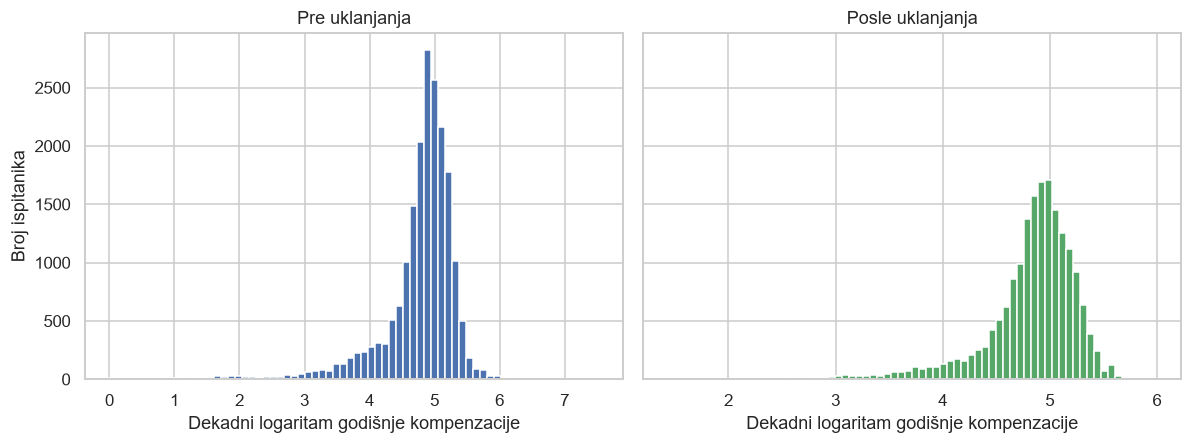

pre uklanjanja:   n=19,461   min=         1   max=  33,552,715   asimetrija= -2.67
posle uklanjanja: n=18,260   min=        27   max=   1,000,000   asimetrija= -1.84

  preostalo ispod   100 USD:    6
  preostalo ispod   500 USD:   44
  preostalo ispod 1,000 USD:  106
  preostalo ispod 2,000 USD:  234

najniža preživela vrednost: 27 USD   Viet Nam, staž 19 god.


In [39]:
kept = target_rows[~target_rows["netipican"]]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)

axes[0].hist(target_rows["log_comp"], bins=70, color="#4C72B0")
axes[0].set_title("Pre uklanjanja")
axes[1].hist(np.log10(kept["ConvertedCompYearly"]), bins=70, color="#55A868")
axes[1].set_title("Posle uklanjanja")

for ax in axes:
    ax.set_xlabel("Dekadni logaritam godišnje kompenzacije")
axes[0].set_ylabel("Broj ispitanika")
plt.tight_layout()
plt.show()

print(f"pre uklanjanja:   n={len(target_rows):>6,}   min={target_rows['ConvertedCompYearly'].min():>10,.0f}   "
      f"max={target_rows['ConvertedCompYearly'].max():>12,.0f}   "
      f"asimetrija={target_rows['log_comp'].skew():>6.2f}")
print(f"posle uklanjanja: n={len(kept):>6,}   min={kept['ConvertedCompYearly'].min():>10,.0f}   "
      f"max={kept['ConvertedCompYearly'].max():>12,.0f}   "
      f"asimetrija={np.log10(kept['ConvertedCompYearly']).skew():>6.2f}")
print()
for limit in [100, 500, 1000, 2000]:
    print(f"  preostalo ispod {limit:>5,} USD: {int((kept['ConvertedCompYearly'] < limit).sum()):>4}")

# Who the lowest surviving value belongs to, so the example in the text is not
# read off the chart.
lowest = kept.nsmallest(1, "ConvertedCompYearly").iloc[0]
print()
print(f"najniža preživela vrednost: {lowest['ConvertedCompYearly']:,.0f} USD   "
      f"{lowest['Country']}, staž {lowest['WorkExp']:.0f} god.")

**Zapažanje:** Ostaje **18.260 ispitanika**. Levi rep je vidno kraći, a koeficijent asimetrije se
popravio sa **−2,67 na −1,84**. Najveća vrednost je pala sa 33,5 miliona na milion dolara.

Ali donji kraj nije potpuno očišćen: preostalo je **6 ispitanika ispod 100 dolara** godišnje i
**106 ispod hiljadu**.

**Tumačenje:** Pravilo po zemlji je uklonilo najveći deo problema i, što je važnije, uklonilo ga je
**bez izbacivanja celih tržišta**. Ali u zemljama sa veoma širokim rasponom plata granica je široka, pa
kroz nju prođe i po koja neuverljivo mala vrednost — najniža preživela je, kako ispis pokazuje,
ispitanik iz Vijetnama sa devetnaest godina staža i prijavljenih dvadeset sedam dolara godišnje.

Mogli bismo da dodamo i donju granicu u apsolutnom iznosu, ali bi to bio broj koji bismo izmislili, a
ne izveli iz podataka — a videli smo koliko takvi pragovi umeju da promaše. Sto šest ispitanika je
0,6% skupa, pa ih ostavljamo i to navodimo kao poznato ograničenje.

Pre nego što odluku prihvatimo, vredi videti koliko zavisi od množioca u ogradi. Vrednost 1,5 je
uobičajena granica boxplota, ali ništa nas ne sprečava da je pomerimo — pa da vidimo šta bi se
dobilo.

In [40]:
for multiplier in [1.0, 1.5, 2.0, 3.0]:
    q1, q3 = target_rows["log_comp"].quantile([0.25, 0.75])
    spread = q3 - q1
    global_flag = ((target_rows["log_comp"] < q1 - multiplier * spread)
                   | (target_rows["log_comp"] > q3 + multiplier * spread))
    country_lo = by_country.transform(lambda s: s.quantile(0.25) - multiplier * (s.quantile(0.75) - s.quantile(0.25)))
    country_hi = by_country.transform(lambda s: s.quantile(0.75) + multiplier * (s.quantile(0.75) - s.quantile(0.25)))
    flag = np.where(small_country, global_flag,
                    (target_rows["log_comp"] < country_lo) | (target_rows["log_comp"] > country_hi))
    remaining = target_rows[~flag]["ConvertedCompYearly"]
    print(f"  množilac {multiplier:>3}:  označeno {int(flag.sum()):>5,} ({100 * flag.mean():>4.1f}%)   "
          f"ostaje {len(remaining):>6,}   minimum {remaining.min():>7,.0f}   "
          f"ispod 1.000 USD: {int((remaining < 1000).sum()):>4}")

  množilac 1.0:  označeno 1,980 (10.2%)   ostaje 17,481   minimum     267   ispod 1.000 USD:   64


  množilac 1.5:  označeno 1,201 ( 6.2%)   ostaje 18,260   minimum      27   ispod 1.000 USD:  106


  množilac 2.0:  označeno   814 ( 4.2%)   ostaje 18,647   minimum      11   ispod 1.000 USD:  141
  množilac 3.0:  označeno   485 ( 2.5%)   ostaje 18,976   minimum       1   ispod 1.000 USD:  171


**Zapažanje:** Stezanje ograde na 1,0 uklonilo bi 1.980 ispitanika umesto 1.201 i podiglo minimum sa
27 na 267 dolara, ali bi i dalje ostavilo 64 vrednosti ispod hiljadu. Popuštanje na 2,0 ili 3,0 ostavlja
sve više neuverljivih iznosa.

**Tumačenje:** Nijedna vrednost množioca ne rešava problem do kraja, pa izbor ne pravimo prema tome
koja daje najlepši rep. Zadržavamo **1,5**, standardnu granicu boxplota koju smo učili na predavanjima,
upravo zato što bi svaka druga bila birana prema željenom ishodu — a to je isti postupak kao kada
bismo prag izmislili.

**Verdikt: hipoteza je potvrđena.** Globalno pravilo je označilo **58,0% svih Pakistanaca i 27,7%
Indijaca, naspram 1,0% ispitanika iz Ujedinjenog Kraljevstva** — raspon koji je daleko iznad
kriterijuma koji smo postavili. Pravilo po zemlji označava 1.201 ispitanika umesto 1.687, a sa
globalnim se poklapa u samo 775 slučajeva, pa razlika između njih nije kozmetička.

**Odluka:** Iz skupa za modelovanje uklanjamo 1.201 ispitanika označenog kao netipičnog, po granicama
računatim unutar zemlje, uz globalno pravilo kao rezervu za 92 zemlje sa manje od trideset ispitanika.
Kod ciljne promenljive uklanjanje reda je jedino što možemo — vrednost se ne sme imputirati, pa red bez
upotrebljive plate nema šta da radi u treningu.

In [41]:
cleaned = cleaned.loc[kept.index].copy()

print(f"populacija posle sekcije 1:      {len(population):>7,}")
print(f"od toga sa prijavljenom platom:  {len(target_rows):>7,}")
print(f"posle uklanjanja netipičnih:     {len(cleaned):>7,}")
print()
print(f"provera: redova bez ciljne promenljive: "
      f"{int(cleaned['ConvertedCompYearly'].isna().sum())}")
print(f"raspon ciljne promenljive: {cleaned['ConvertedCompYearly'].min():,.0f} "
      f"do {cleaned['ConvertedCompYearly'].max():,.0f} USD")

populacija posle sekcije 1:       34,106
od toga sa prijavljenom platom:   19,461
posle uklanjanja netipičnih:      18,260

provera: redova bez ciljne promenljive: 0
raspon ciljne promenljive: 27 do 1,000,000 USD


### Šta je sekcija promenila

Skup za modelovanje je sada **18.260 ispitanika** — od 34.106 iz populacije, kroz izostavljanje onih
bez prijavljene plate i uklanjanje netipičnih vrednosti.

Za razliku od sekcije 4, ovde **jesmo brisali redove**. Razlog je što se radi o ciljnoj promenljivoj:
kod prediktora se pogrešna vrednost može poništiti pa kasnije imputirati, ali plata koju model treba da
nauči ne sme da se izmišlja.

Usput smo odbacili dva postupka pre nego što smo stigli do upotrebljivog: IQR nad sirovim vrednostima
nije video donji kraj, a IQR nad logaritmom je označavao siromašnije zemlje umesto grešaka. Oba
neuspeha su zapisana jer objašnjavaju zašto je konačno pravilo takvo kakvo jeste.

## 6. Izbor kolona

Do sada smo čistili vrednosti; sada odlučujemo koje kolone uopšte ostaju. Anketa ih ima preko sto
sedamdeset, a svaka je nečije pitanje, pa se lako upada u zamku da se sve zadrži „za svaki slučaj".

Zašto to ne valja, najlakše je videti na broju. Kategorijska kolona ne ulazi u model kao jedna
promenljiva nego kao onoliko njih koliko ima kategorija — to je one-hot enkodiranje koje smo učili na
predavanjima. Da vidimo koliko bi kolona nastalo kad bi se svaka takva vrednost enkodirala kao zasebna kategorija.

In [42]:
text_like = [c for c in cleaned.columns if cleaned[c].dtype.kind in "OU"
             or str(cleaned[c].dtype) in ("str", "string")]
naive_columns = sum(cleaned[c].nunique(dropna=True) for c in text_like)

print(f"tekstualnih kolona: {len(text_like)}")
print(f"kolona posle naivnog one-hot enkodiranja: ~{naive_columns:,}")
print(f"redova u skupu: {len(cleaned):,}")

tekstualnih kolona: 119
kolona posle naivnog one-hot enkodiranja: ~159,854
redova u skupu: 18,260


**Zapažanje:** Naivno enkodiranje svih 119 tekstualnih kolona dalo bi oko **159.854 kolone** naspram
**18.260 redova** — skoro devet puta više prediktora nego ispitanika.

**Tumačenje:** Najveći deo tog broja dolazi od multi-select kolona, gde je odgovor jedan string sa svim
izabranim stavkama, pa svaka različita kombinacija postaje sopstvena kategorija. To je usput i
najjasniji argument da se te kolone ne smeju enkodirati kao obične kategorije nego iz njih treba
izvesti nove promenljive — posao koji nas čeka u sledećem notebook-u.

Ali i bez njih broj ostaje prevelik. Kada bi prediktora bilo koliko i opservacija, model bi savršeno
naučio trening skup a na testu ne bi vredeo ništa — kraj bias-variance krive na kom varijansa preuzima
sve.

Ovde ne biramo konačni skup promenljivih; to je posao feature engineeringa i formalne selekcije u
modelovanju. Ovde samo **izbacujemo ono što je neupotrebljivo iz razloga koji nema veze sa modelom**:
kolone koje bi curile, koje ništa ne razlikuju, ili kojih naprosto nema. Svaki kriterijum mora da bude
obrazložen, a granice koje se u njima pojavljuju izvedene iz podataka a ne izabrane.

In [43]:
# Helper flags we added ourselves; they describe our own work, not the respondent.
DERIVED = ["prijavio_platu", "prekinuo_anketu"]

candidates = cleaned.drop(columns=DERIVED)
print(f"kolona na početku: {len(candidates.columns)}")
print(f"redova:            {len(candidates):,}")

kolona na početku: 170
redova:            18,260


### 6.1 Kolone koje bi curile ili ništa ne razlikuju

Prva tri kriterijuma su neposredna i ne traže nikakav račun.

**Ciljna promenljiva i njen izvor.** `ConvertedCompYearly` je ono što predviđamo, pa nije prediktor.
`CompTotal` iz nje sledi deljenjem kursom, što smo u prethodnom notebook-u i dokazali — model bi je
iskoristio da rekonstruiše odgovor umesto da išta nauči.

**Identifikator.** `ResponseId` je redni broj odgovora i ne meri nikakvu osobinu ispitanika.

**Konstantne kolone.** Kolona sa jednom jedinom vrednošću ne razlikuje nijednog ispitanika od drugog,
pa u modelu ne može ništa da doprinese.

In [44]:
drop_reasons = {}


def mark(columns, reason):
    """Record why a column leaves, keeping the first reason that applied."""
    for column in columns:
        drop_reasons.setdefault(column, reason)


mark(["ConvertedCompYearly", "CompTotal"], "ciljna promenljiva i njen izvor")
mark(["ResponseId"], "identifikator")
mark([c for c in candidates.columns if candidates[c].nunique(dropna=True) <= 1], "konstantna")

for reason in dict.fromkeys(drop_reasons.values()):
    columns = [c for c, r in drop_reasons.items() if r == reason]
    print(f"{reason:<32} {len(columns):>3}   {columns}")

ciljna promenljiva i njen izvor    2   ['ConvertedCompYearly', 'CompTotal']


identifikator                      1   ['ResponseId']
konstantna                         1   ['MainBranch']


**Zapažanje:** Po ova tri kriterijuma izlaze četiri kolone. Konstantna je samo `MainBranch`, i to zato
što smo u sekciji 1 populaciju suzili baš po njoj.

**Tumačenje:** Ovo je bilo očekivano i nije donelo iznenađenja. Prava odluka je u sledeća dva
kriterijuma, gde treba postaviti granicu.

### 6.2 Kolone kojih uglavnom nema

Kolona u kojoj nedostaje većina vrednosti ne može mnogo da doprinese, a imputacija nad njom bi značila
da veći deo kolone izmišljamo.

Pitanje je gde povući granicu. Umesto da izaberemo okrugao broj, poređaćemo kolone po udelu
nedostajućih vrednosti i potražiti mesto gde niz **sam pravi prekid**.

In [45]:
missing_share = (candidates.isna().mean() * 100).sort_values()
jumps = missing_share.diff()

print("najveći skokovi u poređanom nizu:")
for column in jumps.nlargest(4).index:
    print(f"  sa {missing_share[column] - jumps[column]:>5.1f}% na {missing_share[column]:>5.1f}%"
          f"   (skok {jumps[column]:.1f} pp, kod kolone {column})")

najveći skokovi u poređanom nizu:
  sa  48.4% na  57.7%   (skok 9.3 pp, kod kolone SOTagsWantToWorkWith)
  sa  74.0% na  79.7%   (skok 5.7 pp, kod kolone AIAgentImpactStrongly agree)
  sa  69.5% na  74.0%   (skok 4.4 pp, kod kolone AIAgentExternal)
  sa  83.1% na  87.2%   (skok 4.1 pp, kod kolone AIAgentImpactStrongly disagree)


### Grafik 6 — gde niz pravi prekid

**Motivacija:** Hoćemo da vidimo kako izgleda poređani niz udela nedostajućih vrednosti i da li je
najveći skok zaista prirodna granica, ili je samo najveći među mnogo sličnih.

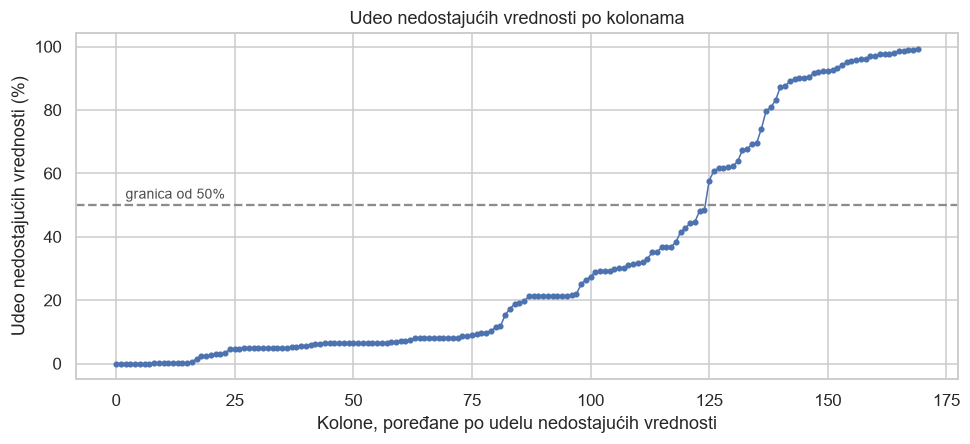

kolona ispod 50%: 125
kolona iznad 50%: 45


In [46]:
fig, ax = plt.subplots(figsize=(9, 4.2))

ax.plot(range(len(missing_share)), missing_share.values, marker="o",
        markersize=3, linewidth=1, color="#4C72B0")
ax.axhline(50, color="#8C8C8C", linestyle="--", linewidth=1.5)
ax.text(2, 52, "granica od 50%", color="#4C4C4C", fontsize=9)

ax.set_xlabel("Kolone, poređane po udelu nedostajućih vrednosti")
ax.set_ylabel("Udeo nedostajućih vrednosti (%)")
ax.set_title("Udeo nedostajućih vrednosti po kolonama")
plt.tight_layout()
plt.show()

print(f"kolona ispod 50%: {int((missing_share < 50).sum())}")
print(f"kolona iznad 50%: {int((missing_share > 50).sum())}")

**Zapažanje:** Kriva raste postepeno do oko pedeset procenata, gde pravi **najveći skok u celom nizu —
sa 48,4% na 57,7%, dakle 9,3 procentna poena odjednom**. Posle toga se nastavlja glatko do vrha. Ispod
te granice je 125 kolona, iznad nje 45.

**Tumačenje:** Prekid nije nešto što smo mi postavili nego nešto što u podacima postoji. Ispod njega su
pitanja koja je većina ispitanika videla, iznad njega pitanja koja su se pojavljivala samo pod
određenim uslovima — pretežno potpitanja o AI agentima, koja su postavljena samo onima koji su rekli da
ih koriste.

Granicu zato postavljamo na **50%**, ne zato što je okrugao broj, nego zato što se tu niz sam prelama.

Vredi napomenuti šta to znači za te kolone: one nisu bezvredne, ali su odgovor na drugačije pitanje.
Kolona koju je popunilo samo 30% ispitanika govori o toj trećini, a ne o celom uzorku, pa bi njeno
zadržavanje značilo da model uči na različitim skupovima ljudi za različite promenljive.

In [47]:
# Where the sorted sequence makes its largest jump, from 48.4% to 57.7%.
MISSING_LIMIT = 50

mark(missing_share[missing_share > MISSING_LIMIT].index, "preko 50% nedostaje")

print(f"izbačeno po ovom kriterijumu: "
      f"{sum(1 for r in drop_reasons.values() if r == 'preko 50% nedostaje')}")
print()
print("primeri:")
for column in list(missing_share[missing_share > MISSING_LIMIT].index)[:6]:
    print(f"  {column:<38} nedostaje {missing_share[column]:.1f}%")

izbačeno po ovom kriterijumu: 45

primeri:
  SOTagsWantToWorkWith                   nedostaje 57.7%
  AIAgentChallengesSomewhat disagree     nedostaje 60.8%
  AIToolPlan to mostly use AI            nedostaje 61.6%
  SOTagsAdmired                          nedostaje 61.8%
  AIAgent_Uses                           nedostaje 61.9%
  AIModelsWantToWorkWith                 nedostaje 62.2%


Među izbačenim kolonama vide se imena poput `AIAgentChallengesSomewhat disagree`, koja na prvi pogled
deluju kao greška. Nisu: šema to pitanje označava kao tip `Matrix`, a takva pitanja Stack Overflow
izvozi tako što ime kolone sastavi od naziva pitanja i teksta ponuđene opcije — pa je ovo opcija
„Somewhat disagree" na pitanju `AIAgentChallenges`. Da vidimo koliko kolona sa slobodnim tekstom uopšte ima.

In [48]:
odd_names = [c for c in cleaned.columns if not re.fullmatch(r"[A-Za-z0-9_]+", c)]
print(f"kolona sa razmakom ili znakom van slova i cifara: {len(odd_names)}")
for name in odd_names[:5]:
    print(f"  {name!r}")
print()
print(f"od njih preživelo dosadašnje kriterijume: "
      f"{len([c for c in odd_names if c not in drop_reasons])}")
print()
question_types = schema.drop_duplicates(subset="qname").set_index("qname")["type"]
print(f"tip pitanja AIAgentChallenges u šemi: {question_types['AIAgentChallenges']}")

kolona sa razmakom ili znakom van slova i cifara: 16
  'SOTagsWant Entry'
  'OpSysPersonal use'
  'OpSysProfessional use'
  'AIToolCurrently partially AI'
  "AIToolDon't plan to use AI for this task"

od njih preživelo dosadašnje kriterijume: 7

tip pitanja AIAgentChallenges u šemi: Matrix


**Zapažanje:** Takvih imena ima **šesnaest**, a dosadašnje kriterijume je preživelo **sedam** od njih.
Šema potvrđuje i objašnjenje: `AIAgentChallenges` je pitanje tipa **Matrix**.

**Tumačenje:** Imena su neuredna ali nisu neispravna, pa ih ne diramo. Ono što je bitno je da ostalih
sedam i dalje moramo da obradimo kao obične kolone, jer kroz njih prolaze isti kriterijumi kao i kroz
sve druge.

### 6.3 Kolone sa slobodnim tekstom

Deo pitanja traži da ispitanik sam upiše odgovor — koji alat koristi ako ga nema na spisku, ili šta
misli o nekoj temi. Takve kolone su upotrebljive tek uz obradu prirodnog jezika, što je van onoga čime
se ovde bavimo.

Prepoznati ih po broju različitih vrednosti nije pouzdano: `Country` ima 177 različitih vrednosti a
sasvim je uredna kategorija. Bolji pokazatelj je **koliko se odgovora javlja samo jednom**. Kod prave
kategorije skoro svaki odgovor deli još neko; kod slobodnog teksta većina je jedinstvena.

In [49]:
# Selecting by dtype kind rather than by name, so the check does not depend on
# whether pandas stores the column as a dedicated string dtype or as object.
def is_text(series):
    return series.dtype.kind in "OU" or str(series.dtype) in ("str", "string")


text_columns_left = [c for c in candidates.columns
                     if c not in drop_reasons and is_text(candidates[c])]

# Multi-select answers are one string with ";" separators; they are handled in
# feature engineering, not here.
multi_select = [c for c in text_columns_left
                if candidates[c].dropna().astype(str).str.contains(";").mean() > 0.3]

uniqueness = {}
for column in text_columns_left:
    if column in multi_select:
        continue
    answers = candidates[column].dropna()
    if len(answers) == 0:
        continue
    counts = answers.value_counts()
    uniqueness[column] = 100 * (counts == 1).sum() / len(answers)

uniqueness = pd.Series(uniqueness).sort_values()
print(f"tekstualnih kolona za proveru: {len(uniqueness)}   "
      f"(multi-select odvojeno: {len(multi_select)})")
print()
print("udeo odgovora koji se javljaju samo jednom:")
for low, high in [(0, 1), (1, 10), (10, 20), (20, 50), (50, 101)]:
    print(f"  {low:>3}-{high:>3}%: {int(((uniqueness >= low) & (uniqueness < high)).sum()):>3} kolona")
print()
print(f"najviši među kategorijama: {uniqueness[uniqueness < 20].max():.2f}%  "
      f"({uniqueness[uniqueness < 20].idxmax()})")
print(f"najniži među slobodnim tekstom: {uniqueness[uniqueness > 20].min():.1f}%  "
      f"({uniqueness[uniqueness > 20].idxmin()})")

tekstualnih kolona za proveru: 37   (multi-select odvojeno: 36)

udeo odgovora koji se javljaju samo jednom:
    0-  1%:  35 kolona
    1- 10%:   0 kolona
   10- 20%:   0 kolona
   20- 50%:   1 kolona
   50-101%:   1 kolona

najviši među kategorijama: 0.13%  (EmploymentAddl)
najniži među slobodnim tekstom: 41.4%  (AIExplain)


**Zapažanje:** Razdvajanje je potpuno, ali kolona za proveru je ostalo manje nego što smo očekivali —
svega **37**, jer je prethodni kriterijum već uklonio većinu. Od njih **35 ima ispod jednog procenta**
jedinstvenih odgovora, a **dve preko dvadeset**. Između jednog i dvadeset procenata **nema nijedne**.

Najviša vrednost među kategorijama je **0,13%** (`EmploymentAddl`), a najniža među kolonama sa slobodnim
tekstom **41,4%** (`AIExplain`). Između te dve vrednosti nema nijedne kolone.

**Tumačenje:** Prag ne moramo da biramo, jer ga podaci sami postavljaju: kolona je ili kategorija u
kojoj se odgovori ponavljaju, ili slobodan tekst u kome skoro svako piše svoje. Stavljamo ga na 20%,
ali bilo gde u praznini dalo bi isti rezultat.

Zanimljivo je da ovaj kriterijum na kraju izbacuje samo dve kolone. Sva ona polja tipa „upišite ako
vašeg alata nema na spisku" već su ispala zbog nedostajućih vrednosti — i to ima smisla, jer ih po
prirodi popunjava mali broj ispitanika. Dva kriterijuma se, dakle, delimično preklapaju, ali svaki
hvata i nešto što onaj drugi ne bi.

`Country` je dobra kontrola — sa 177 različitih vrednosti bi po broju kategorija delovala sumnjivo, ali
po ovom merilu ima svega **0,09%** jedinstvenih odgovora i pada duboko među obične kategorije, gde i
pripada.

In [50]:
# Anywhere inside the empty band between 0.13% and 41.4% gives the same split.
UNIQUE_LIMIT = 20

mark(uniqueness[uniqueness > UNIQUE_LIMIT].index, "slobodan tekst")

free_text = [c for c, r in drop_reasons.items() if r == "slobodan tekst"]
print(f"izbačeno kao slobodan tekst: {len(free_text)}")
print(f"  primeri: {free_text[:5]}")
print()
print(f"provera: Country je zadržan? {'Country' not in drop_reasons}   "
      f"udeo jedinstvenih kod njega: {uniqueness['Country']:.2f}%")

izbačeno kao slobodan tekst: 2
  primeri: ['AIExplain', 'AIOpen']

provera: Country je zadržan? True   udeo jedinstvenih kod njega: 0.09%


### Šta ostaje

In [51]:
kept_columns = [c for c in candidates.columns if c not in drop_reasons]
model_data = candidates[kept_columns].copy()

summary = pd.Series(drop_reasons).value_counts()
print("izbačeno po kriterijumu:")
print(summary.to_string())
print(f"{'ukupno izbačeno':<32} {len(drop_reasons)}")
print()
print(f"kolona pre izbora:  {len(candidates.columns):>4}")
print(f"kolona posle:       {len(model_data.columns):>4}")
print()

numeric_left = model_data.select_dtypes(include="number").columns
still_multi = [c for c in model_data.columns
               if c not in numeric_left
               and model_data[c].dropna().astype(str).str.contains(";").mean() > 0.3]
print("šta je ostalo:")
print(f"  numeričkih:              {len(numeric_left):>4}")
print(f"  multi-select:            {len(still_multi):>4}")
print(f"  običnih kategorijskih:   "
      f"{len(model_data.columns) - len(numeric_left) - len(still_multi):>4}")

izbačeno po kriterijumu:
preko 50% nedostaje                45
ciljna promenljiva i njen izvor     2
slobodan tekst                      2
identifikator                       1
konstantna                          1
ukupno izbačeno                  51

kolona pre izbora:   170
kolona posle:        119



šta je ostalo:
  numeričkih:                48
  multi-select:              36
  običnih kategorijskih:     35


**Zapažanje:** Od 170 kolona izbačena je 51, ostaje ih **119**: 48 numeričkih, 36 multi-select i 35
običnih kategorijskih.

**Tumačenje:** Broj je i dalje velik, i to je u redu — ovaj korak nije trebalo da da konačan skup
promenljivih. On je uklonio ono što je neupotrebljivo bez obzira na model: kolone koje bi curile,
kolone kojih uglavnom nema, i kolone koje su zapravo tekst.

Ono što ostaje nije spremno za model onakvo kakvo jeste. Trideset šest multi-select kolona su i dalje
stringovi sa tačka-zarezom, a četrdeset tri numeričke kolone su rangiranja koja tek treba osmisliti kako
koristiti. To je posao feature engineeringa u sledećem notebook-u, gde se iz njih izvode nove
promenljive, i formalne selekcije u modelovanju, gde se meri koja od njih zaista nosi signal.

## 7. Nedostajuće vrednosti u preostalim kolonama

Nedostajanje ciljne promenljive rešili smo u sekciji 1 — izbacivanjem, jer se plata ne sme izmišljati.
Sada dolaze prediktori, gde je situacija drugačija: red se ne baca zbog jednog praznog polja, nego se
polje popunjava.

Ali pre nego što bilo šta popunimo, treba da razumemo **zašto** vrednost nedostaje. Na predavanjima smo
učili da izbor između brisanja i imputacije zavisi od toga da li je nedostajanje slučajno, i da
imputacija uvek unosi neku pristrasnost. Prazno polje kod nekoga ko je pitanje video i preskočio nije
isto što i prazno polje kod nekoga kome pitanje nije ni prikazano.

In [52]:
features = model_data
missing_share_left = (features.isna().mean() * 100).sort_values(ascending=False)

print(f"kolona u skupu: {len(features.columns)}")
print(f"  bez ijedne nedostajuće vrednosti: {int((missing_share_left == 0).sum())}")
print(f"  sa nedostajućim vrednostima:      {int((missing_share_left > 0).sum())}")
print()
print("kolone bez ijedne nedostajuće vrednosti:")
print(f"  {list(missing_share_left[missing_share_left == 0].index)}")
print()
print("deset sa najviše nedostajućih:")
print(missing_share_left.head(10).round(1).to_string())

kolona u skupu: 119
  bez ijedne nedostajuće vrednosti: 4
  sa nedostajućim vrednostima:      115

kolone bez ijedne nedostajuće vrednosti:
  ['Country', 'DevType', 'Employment', 'Currency']

deset sa najviše nedostajućih:
WebframeAdmired             48.4
AIModelsHaveWorkedWith      48.2
SOTagsHaveWorkedWith        44.7
DatabaseAdmired             44.3
WebframeWantToWorkWith      42.7
PlatformAdmired             41.6
DevEnvsAdmired              38.3
DatabaseWantToWorkWith      36.8
PlatformWantToWorkWith      36.8
AIAgentChallengesNeutral    36.7


**Zapažanje:** Samo **četiri kolone** nemaju nijednu nedostajuću vrednost — `Country`, `DevType`,
`Employment` i `Currency`. To su pitanja sa početka ankete, koja su svi videli. `Age` im je bila peta
dok joj u sekciji 4.2 nismo poništili 92 odgovora „radije ne bih rekao“.

Na drugom kraju su kolone kojima nedostaje između trideset i pedeset posto, uglavnom pitanja o
tehnologijama koje bi ispitanik voleo da koristi.

**Tumačenje:** Ovo je previše kolona da bismo o svakoj odlučivali posebno. Treba nam način da ih
razvrstamo u nekoliko grupa sa istim tretmanom.

Jedan trag imamo od ranije: u sekciji 3 smo videli da se ista grupa ljudi — oni koji su napustili
anketu — pojavljuje u više različitih provera. To sugeriše da nedostajanje nije razbacano po
pojedinačnim poljima nego dolazi u **celim blokovima**, kada neko preskoči čitavo pitanje.

In [53]:
missing_mask = features.isna()

# Columns that are empty for exactly the same respondents belong to one question
# that was skipped as a whole.
patterns = {}
for column in features.columns:
    key = missing_mask[column].values.tobytes()
    patterns.setdefault(key, []).append(column)

blocks = sorted(patterns.values(), key=len, reverse=True)

print(f"kolona: {len(features.columns)}   različitih obrazaca nedostajanja: {len(patterns)}")
print()
print("najveći blokovi kolona koje nedostaju kod istih ispitanika:")
for block in blocks[:5]:
    share = 100 * missing_mask[block[0]].mean()
    print(f"  {len(block):>2} kolona, nedostaje {share:>5.1f}%   {block[:3]}")

kolona: 119   različitih obrazaca nedostajanja: 78

najveći blokovi kolona koje nedostaju kod istih ispitanika:
  13 kolona, nedostaje   6.5%   ['JobSatPoints_1', 'JobSatPoints_4', 'JobSatPoints_5']
  10 kolona, nedostaje   4.9%   ['TechEndorse_1', 'TechEndorse_2', 'TechEndorse_3']
  10 kolona, nedostaje   8.1%   ['TechOppose_1', 'TechOppose_2', 'TechOppose_3']
   9 kolona, nedostaje  21.2%   ['SO_Actions_1', 'SO_Actions_3', 'SO_Actions_4']
   4 kolona, nedostaje   0.0%   ['Employment', 'DevType', 'Country']


**Zapažanje:** 119 kolona ima svega **78 različitih obrazaca** nedostajanja, a četiri najveća bloka
obuhvataju po devet do trinaest kolona.

Najveći od njih dobro pokazuje o čemu je reč. Pitanje „poređaj po važnosti šta ti doprinosi zadovoljstvu
poslom" ima trinaest ponuđenih stavki, pa se u fajlu pojavljuje kao **trinaest kolona** —
`JobSatPoints_1`, `JobSatPoints_4` i tako dalje — od kojih svaka nosi rang jedne stavke. Ispitanik to
pitanje ili poređa u celini ili ga preskoči; nema srednjeg slučaja. Zato su tih trinaest kolona prazne
kod **tačno istih ljudi**, i zajedno čine jedan blok.

**Tumačenje:** Nedostajanje ovde nije pojedinačno nego blokovsko — ne izostaje jedan odgovor, nego celo
pitanje. Brojevi to kažu za najveće blokove, ali se iz njih ne vidi koliko je pojava raširena: da li je
reč o nekoliko pitanja ili o celoj tabeli.

### Grafik 7 — blokovi nedostajanja

**Motivacija:** Brojevi kažu da obrazaca ima 78, ali ne pokazuju kako izgledaju. Crtamo mapu u kojoj je
svaki red ispitanik a svaka kolona jedno pitanje, pa se tamna polja poklapaju sa nedostajućim
vrednostima. Kolone su poređane po sličnosti obrasca, da se vidi da li se grupišu.

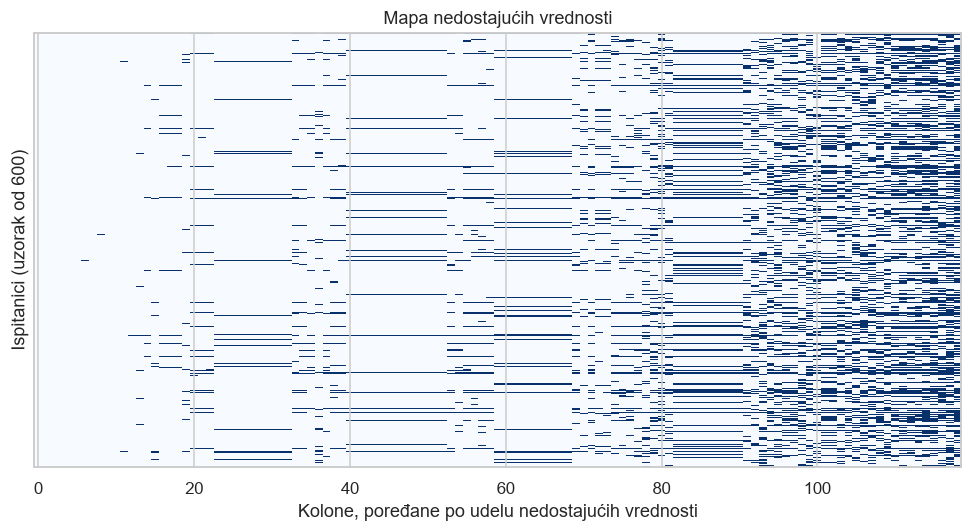

prikazano 600 od 18,260 ispitanika


In [54]:
# One row per respondent, one column per question; dark means the value is missing.
sample = missing_mask.sample(n=600, random_state=7)
column_order_by_pattern = sorted(
    missing_mask.columns, key=lambda c: (missing_mask[c].mean(), c))

fig, ax = plt.subplots(figsize=(9, 5))
ax.imshow(sample[column_order_by_pattern].to_numpy(), aspect="auto",
          cmap="Blues", interpolation="nearest")

ax.set_xlabel("Kolone, poređane po udelu nedostajućih vrednosti")
ax.set_ylabel("Ispitanici (uzorak od 600)")
ax.set_title("Mapa nedostajućih vrednosti")
ax.set_yticks([])
plt.tight_layout()
plt.show()

print(f"prikazano {len(sample)} od {len(missing_mask):,} ispitanika")

**Zapažanje:** Mapa je sastavljena od uspravnih traka. Tamna polja se ne pojavljuju razbacano nego u
širokim pojasevima koji obuhvataju više susednih kolona odjednom, i tamo gde je pojas taman, taman je
kroz čitav niz ispitanika.

**Tumačenje:** Blokovska struktura nije svojstvo samo najvećih pitanja nego se vidi preko cele mape.
Zbog toga je dovoljan jedan indikator po bloku, umesto po jedan za svaku kolonu — što ćemo iskoristiti
u sekciji 9.

Kada neko preskoči celo pitanje, to nije slučajan gubitak podatka nego odluka koja o toj osobi nešto
govori; u sekciji 2 smo i pokazali da je nedostajanje povezano sa posmatranim obeležjima. Zbog toga
imputacija nije jedini put. Kod kategorijskih kolona možemo prazno polje da tretiramo kao **sopstvenu
kategoriju** — „Not answered" — i time zadržimo tu informaciju umesto da je zamenimo najčešćom
vrednošću i tako izbrišemo.

### Šta se sme popuniti a šta ne

Kolone delimo po tome čime bi se popunjavale.

**Kategorijske kolone.** Ovde ne imputiramo. Prazno polje postaje nova kategorija, jer je za kategoriju
to prirodno — model dobija još jednu mogućnost umesto da mu podmetnemo najčešći odgovor. Time
izbegavamo i pristrasnost koju bi popunjavanje modom unelo: najčešća vrednost bi postala još češća.

**Multi-select kolone.** One su i dalje stringovi sa tačka-zarezom i nisu upotrebljive u ovom obliku, pa
se njihovo nedostajanje rešava tek kada se iz njih izvedu nove promenljive, u sledećem notebook-u. Ovde
ih ostavljamo kakve jesu.

**Numeričke kolone.** Ovde imputacija ima smisla, jer nova kategorija ne postoji — broj mora da bude
broj. Popunjavamo medijanom, a ne aritmetičkom sredinom, jer smo videli koliko su raspodele iskošene.

Ali to popunjavanje **ovde ne izvodimo.** Medijana se računa iz podataka, pa ako je izračunamo nad celim
skupom, u nju ulaze i redovi koji će kasnije završiti u test skupu — a test skup bi tada nosio deo
informacije o sebi. Zato prvo delimo podatke, pa tek onda popunjavamo, i to isključivo iz trening
dela.

In [55]:
numeric_features = features.select_dtypes(include="number").columns
multi_select_features = [c for c in features.columns
                         if c not in numeric_features
                         and features[c].dropna().astype(str).str.contains(";").mean() > 0.3]
categorical_features = [c for c in features.columns
                        if c not in numeric_features and c not in multi_select_features]

plan = pd.DataFrame([
    {"grupa": "numeričke", "kolona": len(numeric_features),
     "sa nedostajućim": int((features[numeric_features].isna().sum() > 0).sum()),
     "postupak": "medijana, posle podele"},
    {"grupa": "kategorijske", "kolona": len(categorical_features),
     "sa nedostajućim": int((features[categorical_features].isna().sum() > 0).sum()),
     "postupak": "nova kategorija"},
    {"grupa": "multi-select", "kolona": len(multi_select_features),
     "sa nedostajućim": int((features[multi_select_features].isna().sum() > 0).sum()),
     "postupak": "u feature engineeringu"},
])
print(plan.to_string(index=False))
print()
print(f"ukupno praznih polja u skupu: {int(missing_mask.sum().sum()):,} "
      f"({100 * missing_mask.to_numpy().mean():.1f}% svih ćelija)")

       grupa  kolona  sa nedostajućim               postupak
   numeričke      48               48 medijana, posle podele
kategorijske      35               31        nova kategorija
multi-select      36               36 u feature engineeringu

ukupno praznih polja u skupu: 297,493 (13.7% svih ćelija)


**Zapažanje:** Od 119 kolona, **48 je numeričkih, 36 multi-select i 35 kategorijskih**. Praznih polja
ima **297.493**, što je 13,7% svih ćelija u tabeli.

**Tumačenje:** Raspodela posla je time jasna. Kategorijske kolone rešavamo odmah, novom kategorijom.
Numeričke čekaju podelu na trening i test. Multi-select kolone ne diramo dok se iz njih ne izvedu
promenljive.

Ovde ćemo primeniti samo prvi deo, jer on ne zavisi ni od kakvog računa nad podacima — nova kategorija
je pravilo, ne statistika, pa sme i pre podele.

In [56]:
# Kept in English so it sits alongside the survey's own answer labels.
NOT_ANSWERED = "Not answered"

prepared = features.copy()
affected = [c for c in categorical_features if prepared[c].isna().any()]

for column in affected:
    prepared[column] = prepared[column].astype("object").fillna(NOT_ANSWERED)

print(f"kategorijskih kolona sa nedostajućim: {len(affected)}")
print(f"popunjeno polja: {int(features[affected].isna().sum().sum()):,}")
print()
print("provera na tri kolone:")
for column in affected[:3]:
    share = 100 * (prepared[column] == NOT_ANSWERED).mean()
    print(f"  {column:<22} kategorija „{NOT_ANSWERED}\" nosi {share:>5.1f}% ispitanika")
print()
print(f"preostalo praznih polja u kategorijskim kolonama: "
      f"{int(prepared[categorical_features].isna().sum().sum())}")
print(f"preostalo praznih polja ukupno: {int(prepared.isna().sum().sum()):,}")

kategorijskih kolona sa nedostajućim: 31
popunjeno polja: 24,707

provera na tri kolone:
  Age                    kategorija „Not answered" nosi   0.1% ispitanika
  EdLevel                kategorija „Not answered" nosi   0.0% ispitanika
  EmploymentAddl         kategorija „Not answered" nosi   5.5% ispitanika

preostalo praznih polja u kategorijskim kolonama: 0
preostalo praznih polja ukupno: 272,786


### Šta je sekcija odlučila

Nedostajanje u prediktorima nije razbacano po pojedinačnim poljima nego dolazi u blokovima — 119 kolona
ima svega 78 obrazaca, a najveći blokovi su cela pitanja sa rangiranjem koja je ispitanik preskočio u
celini.

Zato smo za **kategorijske kolone** izabrali novu kategoriju umesto imputacije. Podatak da neko nije
odgovorio time ostaje sačuvan, a u sekciji 2 smo pokazali da taj podatak nije bezvredan.

Za **numeričke kolone** odluka je medijana, ali se izvršava tek u sekciji 9, posle podele na trening i
test. Za **multi-select kolone** ništa se ne radi dok se iz njih ne izvedu promenljive.

Time je sve što se sme uraditi pre podele obavljeno, pa sledi podela.

## 8. Podela na trening i test skup

Sve što smo do sada radili bilo je ili pravilo (nemoguća vrednost, prazan string) ili odluka o tome
koga modelujemo. Ni jedno ni drugo ne zavisi od pojedinačnih brojeva u podacima.

Od ovog trenutka to prestaje da važi. Popunjavanje nedostajućih vrednosti medijanom znači da tu
medijanu **računamo iz podataka**. Ako je izračunamo nad celim skupom, u nju ulaze i redovi koji će
kasnije završiti u test skupu — a test skup tada više nije nezavisna provera, jer je deo informacije o
njemu već ušao u model preko te medijane.

Zato prvo delimo, pa tek onda računamo. Uzimamo uobičajen odnos 80:20 i fiksiramo seme slučajnog
generatora, da podela bude ista pri svakom pokretanju.

In [57]:
from sklearn.model_selection import train_test_split

# The target left the table in section 6, where we were choosing predictors. It
# is not a feature, but it has to travel with the rows into both files.
modelling_set = prepared.join(cleaned["ConvertedCompYearly"])

# Fixed so that re-running the notebook always produces the same split.
RANDOM_STATE = 42
# One fifth held out; the usual split when the sample is this large.
TEST_SHARE = 0.2

train_set, test_set = train_test_split(
    modelling_set, test_size=TEST_SHARE, random_state=RANDOM_STATE)

print(f"kolona u skupu: {len(modelling_set.columns)}   "
      f"({len(modelling_set.columns) - 1} prediktora + ciljna promenljiva)")
print()
print(f"ukupno:  {len(modelling_set):>7,}")
print(f"trening: {len(train_set):>7,}  ({100 * len(train_set) / len(modelling_set):.1f}%)")
print(f"test:    {len(test_set):>7,}  ({100 * len(test_set) / len(modelling_set):.1f}%)")

kolona u skupu: 120   (119 prediktora + ciljna promenljiva)

ukupno:   18,260
trening:  14,608  (80.0%)
test:      3,652  (20.0%)


Podela je nasumična, pa nema garancije da su dva skupa slična po sastavu. Kod velikih uzoraka to
obično jeste tako, ali „obično jeste" nije provera — pa da uporedimo ono što nam je najvažnije: ciljnu
promenljivu i raspodelu po zemljama.

In [58]:
comparison = pd.DataFrame({
    "trening": train_set["ConvertedCompYearly"].describe(percentiles=[0.25, 0.5, 0.75]),
    "test": test_set["ConvertedCompYearly"].describe(percentiles=[0.25, 0.5, 0.75]),
}).round(0)
print(comparison.to_string())
print()

share_train = train_set["Country"].value_counts(normalize=True) * 100
share_test = test_set["Country"].value_counts(normalize=True) * 100
countries = pd.DataFrame({"trening_%": share_train, "test_%": share_test}).dropna()
countries["razlika_pp"] = (countries["test_%"] - countries["trening_%"]).abs()

print("najveće razlike u udelu zemalja:")
print(countries.sort_values("razlika_pp", ascending=False).head(5).round(2).to_string())

         trening      test
count    14608.0    3652.0
mean     94499.0   93765.0
std      67862.0   66418.0
min         27.0      96.0
25%      48726.0   47886.0
50%      81210.0   81210.0
75%     125000.0  125000.0
max    1000000.0  580073.0

najveće razlike u udelu zemalja:
                          trening_%  test_%  razlika_pp
Country                                                
United States of America      21.94   20.76        1.18
Switzerland                    1.46    2.14        0.67
Australia                      2.53    1.89        0.64
France                         4.42    3.97        0.44
Romania                        0.86    1.26        0.40


**Zapažanje:** Medijana kompenzacije je u oba skupa ista, **81.210 dolara**, a najveća razlika u udelu
neke zemlje je **1,18 procentnih poena**, kod Sjedinjenih Država.

**Tumačenje:** Nasumična podela je pri ovoj veličini uzorka dala uravnotežene skupove. Razlika od
1,18 procentnih poena kod Sjedinjenih Država, pri udelu od oko dvadeset dva posto, znači da je u testu
tridesetak ljudi manje nego što bi bilo pri savršeno jednakom sastavu — što ni na jedno merenje ne
utiče. Da li bi stratifikovana podela dala bolji sastav, ne pretpostavljamo nego proveravamo odmah
ispod.

Od ovog trenutka **test skup ne diramo.** Sve što sledi računa se isključivo iz trening skupa, a na
test se samo primenjuje.

Podela je nasumična, pa se oslanjamo na to da je slučaj dobro ispao. Postoji i postupak koji to ne
prepušta slučaju — **stratifikovana podela**. Ona skup prvo razbije na grupe po nekom obeležju, pa
**iz svake grupe posebno** izdvoji petinu u test skup. Time oba skupa po tom obeležju dobijaju isti
sastav po konstrukciji, a ne po sreći.

Kod nas se ciljna promenljiva ne može stratifikovati direktno, jer je neprekidna — plata ima skoro
šest hiljada različitih vrednosti, pa svaka „grupa" ima po jednog čoveka. Zaobilazi se tako što se
plata prvo podeli na **decile**, pa se stratifikuje po njima. Drugi razuman izbor je **zemlja**, jer
smo u sekciji 2 videli koliko ona utiče na sve.

Probamo oba i uporedimo sa nasumičnom podelom koju već imamo.

In [59]:
# Pay is continuous, so it is split into ten equal groups first; a stratified
# split then takes a fifth out of each of them.
pay_decile = pd.qcut(modelling_set["ConvertedCompYearly"], 10, labels=False, duplicates="drop")

# Stratifying by country outright is impossible: a class needs at least two
# members and some countries have exactly one respondent. Those are pooled, the
# same way the country column is reduced later on.
country_counts = modelling_set["Country"].value_counts()
rare = country_counts[country_counts < 2].index
country_strata = modelling_set["Country"].where(~modelling_set["Country"].isin(rare), "Ostalo")
print(f"zemalja sa jednim jedinim ispitanikom: {len(rare)}   "
      f"(stratifikacija ih ne može razdvojiti, pa ulaze u „Ostalo\")")
print()

variants = {"nasumična (koristimo ovu)": train_set,
            "stratifikovano po decilu plate": None,
            "stratifikovano po zemlji": None}
variants["stratifikovano po decilu plate"] = train_test_split(
    modelling_set, test_size=TEST_SHARE, random_state=RANDOM_STATE, stratify=pay_decile)[0]
variants["stratifikovano po zemlji"] = train_test_split(
    modelling_set, test_size=TEST_SHARE, random_state=RANDOM_STATE,
    stratify=country_strata)[0]

print(f"{'podela':<32} {'medijana trening':>17} {'medijana test':>14} "
      f"{'najveća razlika po zemlji':>26}")
for label, part in variants.items():
    rest = modelling_set.drop(part.index)
    share_a = part["Country"].value_counts(normalize=True) * 100
    share_b = rest["Country"].value_counts(normalize=True) * 100
    gap = (share_b - share_a).abs().dropna().max()
    print(f"{label:<32} {part['ConvertedCompYearly'].median():>17,.0f} "
          f"{rest['ConvertedCompYearly'].median():>14,.0f} {gap:>25.2f} pp")

zemalja sa jednim jedinim ispitanikom: 17   (stratifikacija ih ne može razdvojiti, pa ulaze u „Ostalo")

podela                            medijana trening  medijana test  najveća razlika po zemlji
nasumična (koristimo ovu)                   81,210         81,210                      1.18 pp
stratifikovano po decilu plate              81,210         81,210                      0.76 pp
stratifikovano po zemlji                    81,210         81,210                      0.01 pp


**Zapažanje:** Medijana plate je **81.210 dolara u sve tri podele**, i u trening i u test skupu. Po
sastavu zemalja se razlikuju: najveća razlika u udelu neke zemlje je **1,18 procentnih poena** kod
nasumične podele, **0,76** kod stratifikacije po decilu plate, i **0,01** kod stratifikacije po zemlji.

Usput se vidi i jedno ograničenje samog postupka: **17 zemalja ima po jednog jedinog ispitanika**, a
stratifikacija traži bar dva člana po grupi, pa se te zemlje moraju spojiti u „Ostalo" pre nego što se
uopšte može primeniti.

**Tumačenje:** stratifikacija po zemlji radi tačno ono što obećava — razliku u sastavu svodi na stotinu
puta manju, praktično na nulu. Pitanje je da li nam to treba.

Razlika od 1,18 procentnih poena tiče se udela od oko dvadeset dva posto, dakle tridesetak ljudi u test
skupu. Za merenja koja slede to je premalo da išta pomeri, a medijana plate — ono što zapravo
modelujemo — ista je u sve tri podele.

**Zadržavamo nasumičnu podelu**, jer je jednostavnija i jer razlika koju stratifikacija uklanja nije
takva da bi menjala ijedan zaključak. Ovo sada nije pretpostavka nego izmereno; ranije smo se oslanjali
na to da je uzorak velik, a sada znamo i koliko tačno gubimo time što ne stratifikujemo.

## 9. Imputacija numeričkih kolona

Ostale su numeričke kolone sa nedostajućim vrednostima. Kategorijske smo rešili u sekciji 7 novom
kategorijom, ali kod broja to ne ide — broj mora da bude broj.

Numeričkih prediktora ima 48, ali nisu iste prirode. Pet njih meri veličine sa jasnim značenjem, a
preostale 43 su rangiranja iz četiri pitanja. Krećemo od prvih pet.

In [60]:
# The four ranking questions found in section 4.5.
RANK_PREFIXES_KNOWN = ["TechEndorse", "TechOppose", "JobSatPoints", "SO_Actions"]

# The target rejoined the table before the split, but it is not a predictor and
# is never imputed, so it stays out of everything this section does.
numeric_columns = [c for c in train_set.select_dtypes(include="number").columns
                   if c != "ConvertedCompYearly"]
rank_columns = [c for c in numeric_columns
                if any(c.startswith(p) for p in RANK_PREFIXES_KNOWN)]
plain_numeric = [c for c in numeric_columns if c not in rank_columns]

print(f"numeričkih prediktora: {len(numeric_columns)}   "
      f"od toga rangiranja: {len(rank_columns)}   ostalih: {len(plain_numeric)}")
print()
print("nedostajuće vrednosti u trening skupu:")
print((train_set[plain_numeric].isna().mean() * 100).round(1).to_string())

numeričkih prediktora: 48   od toga rangiranja: 43   ostalih: 5

nedostajuće vrednosti u trening skupu:
WorkExp               1.5
YearsCode             0.4
ToolCountWork        15.1
ToolCountPersonal    24.9
JobSat                3.4


**Zapažanje:** Kod `WorkExp` nedostaje **1,5%**, kod `YearsCode` **0,4%**, kod zadovoljstva poslom
**3,4%**, a kod broja alata znatno više — **15,1%** i **24,9%**. Brojevi su manji nego u sekciji 4
jer se mere na trening skupu, koji je uži od populacije: u međuvremenu su izostavljeni redovi bez
prijavljene plate i netipične vrednosti.

**Tumačenje:** Najjednostavnije rešenje je da svima upišemo istu vrednost, **medijanu te kolone
izračunatu nad svim ispitanicima**. Nazivaćemo je opštom medijanom.

Ali možemo i bolje. Ispitanike umemo da razvrstamo u grupe po nekom obeležju koje već imamo — recimo
po starosnoj kategoriji — pa da **medijanu iste te kolone izračunamo posebno unutar svake grupe**, i
svakome upišemo medijanu njegove grupe. Kod staža to deluje razumno, jer je staž očigledno povezan sa
uzrastom.

Da ne bude zabune oko toga šta se čime računa: medijana se uvek uzima od **kolone koju popunjavamo**,
recimo od `WorkExp`. Obeležje po kom grupišemo, recimo `Age`, služi samo da ispitanike razvrsta u
grupe; ono samo ne mora ni da bude broj, a `Age` i nije — to su kategorije poput „25-34 years old".
Grupisanje po `Country` znači da medijanu staža računamo posebno za svaku zemlju.

Umesto da pretpostavimo koje grupisanje pomaže, izmerićemo. Uzimamo redove u kojima vrednost
**postoji**, nasumično sakrijemo petinu njih, popunimo je svakim od postupaka, i uporedimo koliko su
predviđanja promašila. Sve se računa isključivo nad trening skupom.

In [61]:
def compare_imputations(data, column, groupings, hidden_share=0.2, seed=0):
    """Hide part of the known values and see which fill comes closest.

    The median is always taken of `column`; each entry in `groupings` is only
    used to split respondents into groups first.
    """
    frame = data[[column] + list(dict.fromkeys(groupings))].dropna()
    rng = np.random.default_rng(seed)
    hidden = rng.random(len(frame)) < hidden_share
    known, checked = frame[~hidden], frame[hidden]

    overall_median = known[column].median()
    errors = {"jedna medijana za sve": np.abs(overall_median - checked[column]).mean()}
    for grouping in groupings:
        group_median = known.groupby(grouping)[column].median()
        # Groups unseen among the known values fall back to the overall median.
        filled = checked[grouping].map(group_median).fillna(overall_median)
        errors[f"medijana unutar grupa po {grouping}"] = np.abs(filled - checked[column]).mean()

    return pd.Series(errors).round(3), len(frame)


for column, groupings in [("WorkExp", ["Age", "Country", "EdLevel"]),
                          ("YearsCode", ["Age", "Country"]),
                          ("JobSat", ["Country", "Age"]),
                          ("ToolCountWork", ["DevType", "Age"]),
                          ("ToolCountPersonal", ["DevType", "Age"])]:
    errors, size = compare_imputations(train_set, column, groupings)
    best = errors.idxmin()
    print(f"popunjavamo {column}  (n={size:,})")
    for name, value in errors.items():
        marker = "  <- najbolje" if name == best else ""
        print(f"    {name:<34} prosečna greška {value:>7.3f}{marker}")
    print()

popunjavamo WorkExp  (n=14,386)
    jedna medijana za sve              prosečna greška   7.276
    medijana unutar grupa po Age       prosečna greška   3.373  <- najbolje
    medijana unutar grupa po Country   prosečna greška   7.016
    medijana unutar grupa po EdLevel   prosečna greška   7.213

popunjavamo YearsCode  (n=14,543)
    jedna medijana za sve              prosečna greška   8.298
    medijana unutar grupa po Age       prosečna greška   4.571  <- najbolje
    medijana unutar grupa po Country   prosečna greška   7.933

popunjavamo JobSat  (n=14,109)
    jedna medijana za sve              prosečna greška   1.447
    medijana unutar grupa po Country   prosečna greška   1.427  <- najbolje
    medijana unutar grupa po Age       prosečna greška   1.444

popunjavamo ToolCountWork  (n=12,400)
    jedna medijana za sve              prosečna greška   4.417
    medijana unutar grupa po DevType   prosečna greška   4.380
    medijana unutar grupa po Age       prosečna greška   4.376  <- 

**Zapažanje:** Kod **`WorkExp` grupisanje po uzrastu više nego prepolovljuje grešku** — sa 7,276 na
3,373 godine. Kod `YearsCode` je slično, sa 8,298 na 4,571.

Kod ostale tri kolone razlika je zanemarljiva: `JobSat` ide sa 1,447 na 1,427, `ToolCountWork` sa 4,417
na 4,376, `ToolCountPersonal` sa 3,250 na 3,235. Formalno je i tu grupisanje „najbolje", ali dobitak je
u trećoj decimali.

Zanimljivo je i da kod staža grupisanje **po zemlji** ne pomaže skoro ništa (7,016 naspram 7,276),
iako smo u sekciji 5 videli koliko se nivo plate razlikuje među zemljama.

**Tumačenje:** Rezultat je lako objasniti. Staž je vezan za uzrast — ko ima trideset godina ne može
imati trideset godina staža — pa poznavanje starosne kategorije stvarno sužava opseg mogućih vrednosti.
Zemlja o stažu ne govori ništa, i merenje to potvrđuje — razlika među zemljama koju smo videli kod
plata na staž se ne prenosi.

Kod broja alata i zadovoljstva poslom nijedno grupisanje ne donosi stvarnu razliku, pa uzimamo jednu
medijanu za sve — nema razloga za složeniji postupak koji ne daje bolji rezultat.

**Odluka:** `WorkExp` i `YearsCode` popunjavamo medijanom unutar starosne kategorije, ostale jednom
medijanom za sve. Sve medijane računaju se na trening skupu i istim vrednostima se popunjava i test.

### Šta gubimo popunjavanjem

Čim vrednost popunimo, podatak o tome da je nedostajala nestaje. Svi ispitanici dobiju broj, pa se više
ne vidi ko je zaista odgovorio a ko nije. A u sekciji 2 smo pokazali da to nije nevažna informacija —
ko je nešto preskočio sistematski se razlikuje od onoga ko nije.

Kod kategorijskih kolona to smo sačuvali samom kategorijom „Not answered". Kod numeričkih moramo
posebno, i to **pre** popunjavanja, jer posle više nema šta da se zabeleži.

Rešenje je nova kolona koja pamti stanje pre popunjavanja: **1 ako je vrednost nedostajala, 0 ako
nije.** Takvu kolonu zovemo indikatorom.

Ne pravimo je za svaku od 48 kolona. Pošto svih trinaest `JobSatPoints` kolona nedostaje kod istih
ljudi, trinaest indikatora bilo bi trinaest istovetnih kolona — dovoljan je **jedan po bloku**.
Preskačemo i blokove kod kojih nedostaje manje od procenta ispitanika, jer tamo indikator praktično
nema šta da razlikuje.

In [62]:
# Below one percent an indicator would have almost nothing to separate.
INDICATOR_LIMIT = 1.0

# Columns missing for exactly the same respondents come from one question, so a
# single indicator describes the whole block.
missing_numeric = train_set[numeric_columns].isna()
numeric_blocks = {}
for column in numeric_columns:
    key = missing_numeric[column].values.tobytes()
    numeric_blocks.setdefault(key, []).append(column)

indicator_for = {}
for block in numeric_blocks.values():
    share = 100 * missing_numeric[block[0]].mean()
    if share >= INDICATOR_LIMIT:
        indicator_for[f"NotAnswered_{block[0]}"] = block

print(f"blokova među numeričkim kolonama: {len(numeric_blocks)}")
print(f"indikatora koje dodajemo:         {len(indicator_for)}")
print()
for name, block in indicator_for.items():
    share = 100 * missing_numeric[block[0]].mean()
    print(f"  {name:<32} pokriva {len(block):>2} kolona, nedostaje {share:>5.1f}%")


def add_indicators(frame):
    marked = frame.copy()
    for name, block in indicator_for.items():
        marked[name] = frame[block[0]].isna().astype(int)
    return marked


train_set = add_indicators(train_set)
test_set = add_indicators(test_set)

print()
print(f"kolona posle dodavanja indikatora: {len(train_set.columns)}")
print()

# Two respondents, before the filling happens, to show what the indicator holds.
example_block = indicator_for["NotAnswered_JobSatPoints_1"][:6]
answered = train_set[train_set["NotAnswered_JobSatPoints_1"] == 0].iloc[0]
skipped = train_set[train_set["NotAnswered_JobSatPoints_1"] == 1].iloc[0]

print("ispitanik koji JESTE rangirao:")
print(f"  {[None if pd.isna(answered[c]) else int(answered[c]) for c in example_block]} ..."
      f"   indikator = {int(answered['NotAnswered_JobSatPoints_1'])}")
print("ispitanik koji NIJE rangirao (vrednosti još nisu popunjene):")
print(f"  {[None if pd.isna(skipped[c]) else int(skipped[c]) for c in example_block]} ..."
      f"   indikator = {int(skipped['NotAnswered_JobSatPoints_1'])}")

blokova među numeričkim kolonama: 10
indikatora koje dodajemo:         9

  NotAnswered_WorkExp              pokriva  1 kolona, nedostaje   1.5%
  NotAnswered_TechEndorse_1        pokriva 10 kolona, nedostaje   5.1%
  NotAnswered_TechOppose_1         pokriva 10 kolona, nedostaje   8.1%
  NotAnswered_JobSatPoints_1       pokriva 13 kolona, nedostaje   6.5%
  NotAnswered_ToolCountWork        pokriva  1 kolona, nedostaje  15.1%
  NotAnswered_ToolCountPersonal    pokriva  1 kolona, nedostaje  24.9%
  NotAnswered_SO_Actions_1         pokriva  9 kolona, nedostaje  21.0%
  NotAnswered_SO_Actions_16        pokriva  1 kolona, nedostaje  27.3%
  NotAnswered_JobSat               pokriva  1 kolona, nedostaje   3.4%

kolona posle dodavanja indikatora: 129



ispitanik koji JESTE rangirao:
  [12, 10, 11, 13, 4, 2] ...   indikator = 0
ispitanik koji NIJE rangirao (vrednosti još nisu popunjene):
  [None, None, None, None, None, None] ...   indikator = 1


In [63]:
# Columns where grouping by age band measurably beat the overall median.
BY_AGE = ["WorkExp", "YearsCode"]
# Columns where no grouping helped, so the plain median is enough.
BY_OVERALL = ["JobSat", "ToolCountWork", "ToolCountPersonal"]

# Every fill value is computed on the training set only, then applied to both.
age_medians = {c: train_set.groupby("Age")[c].median() for c in BY_AGE}
overall_medians = {c: train_set[c].median() for c in BY_OVERALL + BY_AGE}
rank_medians = {c: train_set[c].median() for c in rank_columns}


def impute(frame):
    filled = frame.copy()
    for column in BY_AGE:
        by_age = filled["Age"].map(age_medians[column])
        filled[column] = filled[column].fillna(by_age).fillna(overall_medians[column])
    for column in BY_OVERALL:
        filled[column] = filled[column].fillna(overall_medians[column])
    for column in rank_columns:
        filled[column] = filled[column].fillna(rank_medians[column])
    return filled


train_filled = impute(train_set)
test_filled = impute(test_set)

multi_select_left = [c for c in train_filled.columns
                     if train_filled[c].dtype.kind in "OU"
                     and train_filled[c].dropna().astype(str).str.contains(";").mean() > 0.3]

for name, before, after in [("trening", train_set, train_filled),
                            ("test", test_set, test_filled)]:
    numeric_left = int(after[numeric_columns].isna().sum().sum())
    multi_left = int(after[multi_select_left].isna().sum().sum())
    print(f"{name}:")
    print(f"  praznih polja pre imputacije:      {int(before.isna().sum().sum()):>8,}")
    print(f"  posle, u numeričkim kolonama:      {numeric_left:>8,}")
    print(f"  posle, u multi-select kolonama:    {multi_left:>8,}   (namerno ostavljeno)")
print()
print("medijana staža po starosnoj kategoriji, izračunata na treningu:")
print(age_medians["WorkExp"].to_string())

trening:
  praznih polja pre imputacije:       217,948
  posle, u numeričkim kolonama:             0
  posle, u multi-select kolonama:     148,085   (namerno ostavljeno)
test:
  praznih polja pre imputacije:        54,838
  posle, u numeričkim kolonama:             0
  posle, u multi-select kolonama:      37,171   (namerno ostavljeno)

medijana staža po starosnoj kategoriji, izračunata na treningu:
Age
18-24 years old       2.0
25-34 years old       7.0
35-44 years old      15.0
45-54 years old      25.0
55-64 years old      34.0
65 years or older    44.0
Not answered         18.0


**Zapažanje:** U numeričkim kolonama više nema nijedne prazne vrednosti. Ostalo je oko 148 hiljada
praznih polja u trening skupu, ali sva su u **multi-select kolonama**, koje smo namerno ostavili
netaknute. Medijane staža po starosnoj kategoriji rastu onako kako se i očekuje, od dve godine kod
najmlađih do četrdeset četiri kod najstarijih.

**Tumačenje:** Multi-select kolona je i dalje jedan string sa svim izabranim stavkama, pa popunjavanje
nema smisla dok se iz nje ne izvedu prave promenljive — a tada prazna vrednost prirodno postaje nula
izabranih stavki. To je posao sledećeg notebook-a.

Rangiranja smo popunili jednom medijanom bez posebne provere, jer je kod njih nedostajanje blokovsko —
ispitanik nije preskočio jednu stavku nego celo pitanje, pa nema susedne vrednosti iz koje bi se izvelo
nešto pametnije. Medijanski rang je u tom slučaju najneutralniji izbor.

Podatak o tome ko nije odgovorio nije izgubljen: sačuvan je u devet indikatorskih kolona koje smo
dodali pre popunjavanja. Ispis iznad pokazuje i zašto su nam trebale — ispitanik koji je pitanje
preskočio sada ima iste takve brojeve kao i onaj koji je odgovorio, pa je indikator jedino mesto na kom
ta razlika i dalje postoji. Da li one nose signal, proverava se tek u modelovanju — ovde smo samo obezbedili da
informacija ostane dostupna.

## 10. Čuvanje očišćenog skupa

Ostaje da očišćene podatke sačuvamo, jer su oni jedan od isporučivih rezultata rada. Trening i test
čuvamo odvojeno, da podela ostane fiksirana i da se u kasnijim koracima ne može slučajno promeniti.

Fajlove zapisujemo kao **CSV sažet gzip-om**. Nesažet CSV bi bio višestruko veći, uglavnom zbog
multi-select kolona u kojima se iste duge liste tehnologija ponavljaju kroz hiljade redova — a upravo
takav sadržaj se izvrsno sažima. Koliko se time dobija, vidi se u ispisu ispod. Format ostaje običan
CSV, pa se čita jednim pozivom `pd.read_csv` bez ikakvih dodatnih biblioteka.

In [64]:
PROCESSED_DIR = Path.cwd().parent / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

train_path = PROCESSED_DIR / "train.csv.gz"
test_path = PROCESSED_DIR / "test.csv.gz"

train_filled.to_csv(train_path, index=False, encoding="utf-8", compression="gzip")
test_filled.to_csv(test_path, index=False, encoding="utf-8", compression="gzip")

MB = 1024 ** 2
for path, frame in ((train_path, train_filled), (test_path, test_filled)):
    # Size of the same CSV without compression, so the gain is a measured number
    # rather than an estimate.
    plain = len(frame.to_csv(index=False).encode("utf-8"))
    packed = path.stat().st_size
    print(f"{path.name:<14} {packed / MB:>5.1f} MB sažeto   {plain / MB:>5.1f} MB nesažeto   "
          f"({plain / packed:.0f} puta manje)")

train.csv.gz     4.3 MB sažeto    42.3 MB nesažeto   (10 puta manje)


test.csv.gz      1.1 MB sažeto    10.5 MB nesažeto   (10 puta manje)


In [65]:
# Reading the files back is the only way to be sure they hold what we think.
train_check = pd.read_csv(train_path, low_memory=False)
test_check = pd.read_csv(test_path, low_memory=False)

print(f"trening: {train_check.shape[0]:>6,} redova x {train_check.shape[1]} kolona")
print(f"test:    {test_check.shape[0]:>6,} redova x {test_check.shape[1]} kolona")
print()
target_present = (train_check["ConvertedCompYearly"].notna().all()
                  and test_check["ConvertedCompYearly"].notna().all())
print(f"ciljna promenljiva prisutna u svim redovima: {target_present}")
print(f"medijana kompenzacije: trening {train_check['ConvertedCompYearly'].median():,.0f} USD, "
      f"test {test_check['ConvertedCompYearly'].median():,.0f} USD")
print()
numeric_after = train_check.select_dtypes(include="number").columns
print(f"praznih polja u numeričkim kolonama posle čitanja: "
      f"{int(train_check[numeric_after].isna().sum().sum()):,}")
print(f"ukupno praznih polja posle čitanja: {int(train_check.isna().sum().sum()):,} "
      f"(sve u multi-select kolonama)")

trening: 14,608 redova x 129 kolona
test:     3,652 redova x 129 kolona

ciljna promenljiva prisutna u svim redovima: True
medijana kompenzacije: trening 81,210 USD, test 81,210 USD

praznih polja u numeričkim kolonama posle čitanja: 0
ukupno praznih polja posle čitanja: 148,085 (sve u multi-select kolonama)


**Zapažanje:** Oba fajla se čitaju bez greške, imaju očekivan broj redova i kolona, ciljna promenljiva
je prisutna u svakom redu, a medijane kompenzacije se poklapaju sa onima pre čuvanja. U numeričkim
kolonama nema praznih polja; ona koja ostaju su u multi-select kolonama, kako smo i ostavili.

**Tumačenje:** Provera čitanjem nije suvišna. Zapis u CSV i čitanje nazad mogu da promene tipove
kolona ili da unesu prazne vrednosti tamo gde ih nije bilo, pa je jedini način da se u sadržaj fajla
bude siguran taj da se on stvarno pročita.

## Zaključak notebook-a

Pošli smo od **49.123 ispitanika i 170 kolona**, a završavamo sa **18.260 ispitanika i 129 kolona**, od kojih je jedna
ciljna promenljiva a ostalo prediktori, podeljenih na trening i test skup. Od tih prediktora je devet
indikatora koje smo sami dodali, da se ne izgubi podatak o tome ko na neko pitanje nije odgovorio.

Redosled odluka bio je sledeći:

1. **Populacija** — zadržali smo programere po profesiji koji trenutno rade, kao zaposleni ili
   samostalni. Odluka je doneta poređenjem raspodela zarade, a ne po osećaju.
2. **Nedostajanje ciljne promenljive** — pokazali smo da nije slučajno, jer udeo prijavljivanja po
   zemljama ide od 54% do 88%. Brisanje smo ipak zadržali, jer se plata ne sme izmišljati, ali uz
   obavezu da zemlja uđe u model i da se pristrasnost navede kao ograničenje.
3. **Duplikati** — pravih nema; 741 red koji je izgledao kao duplikat pripada ljudima koji su napustili
   anketu posle nekoliko pitanja.
4. **Strukturne greške** — ispravljen zapis u tekstualnim kolonama, poništene nemoguće vrednosti staža
   i broja alata, bez brisanja ijednog reda.
5. **Netipične vrednosti** — merene unutar zemlje, jer je globalno pravilo označavalo siromašnije
   zemlje umesto grešaka.
6. **Izbor kolona** — izbačena 51 kolona po pet kriterijuma, sa granicama izvedenim iz podataka.
7. **Nedostajanje kod prediktora** — kategorijske kolone dobile su kategoriju „Not answered", jer sama
   činjenica da neko nije odgovorio nosi informaciju.
8. **Podela** — 80:20, uz proveru da su skupovi uravnoteženi.
9. **Imputacija** — medijana, po starosnoj kategoriji tamo gde merenje pokazuje da to pomaže, uz devet
   indikatora dodatih pre popunjavanja.
10. **Čuvanje** — u `data/processed/`, uz proveru čitanjem.

Ono što ostaje otvoreno i prenosi se dalje: pristrasnost uzorka prema bogatijim zemljama, stotinak
neuverljivo malih iznosa koje pravilo po zemlji nije uhvatilo, i trideset šest multi-select kolona koje su i dalje neobrađene.

Sledeći notebook bavi se izvođenjem novih promenljivih iz kolona koje su ovde samo raščišćene.